# Qwen3-8B Benchmark Results — Full Analysis

**Model:** Qwen/Qwen3-8B on GKE (NVIDIA GPU)  
**Engine:** vLLM · tensor-parallel 1  
**Load generator:** Locust (streaming SSE)

## Two test runs

| Run | ID | Experiments | Concurrency | Purpose |
|-----|----|-------------|-------------|--------|
| **Run 1** | `run_20260404_181323` | reasoning_baseline, non_reasoning_baseline | 16, 32, 64 | Reasoning vs Non-Reasoning comparison |
| **Run 2** | `run_20260405_005704` | qwen3_kv_cache_auto, qwen3_kv_cache_fp8 | 16, 32, 64, 128 | KV Cache dtype impact (auto vs fp8) |

### Metrics captured
- **Client-side (Locust):** TTFT, TPOT, E2E latency, ITL p50/p99, throughput
- **Server-side (Prometheus):** GPU utilization %, VRAM, KV cache %, queue depth, generation throughput, TTFT/TPOT/ITL/E2E percentiles

In [1]:
import glob, json, os, textwrap, warnings, re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 200,
    'font.size': 10,
    'axes.titlesize': 12,
    'figure.titlesize': 14,
})

# ─── Configuration ────────────────────────────────────────────────────────────
RESULTS_ROOT = Path('results')

# Run IDs
RUN1_ID = 'run_20260404_181323'   # Reasoning vs Non-Reasoning
RUN2_ID = 'run_20260405_005704'   # KV Cache dtype comparison

# GPU cost (GKE pricing — adjust as needed)
GPU_HOURLY_COST_USD = 1.58
# ──────────────────────────────────────────────────────────────────────────────

In [2]:
# ─── Helper: load one run's Locust custom-metrics CSVs ────────────────────────
def load_run_locust(run_dir: Path, run_label: str) -> pd.DataFrame:
    """Return a DataFrame with all custom_metrics rows, tagged with experiment / users / run."""
    frames = []
    for csv_path in sorted(run_dir.rglob('*custom_metrics*.csv')):
        stem = csv_path.stem
        exp  = csv_path.parent.name
        # Extract user count from filename pattern: expname__uNN or expname__uNN_custom_metrics
        m = re.search(r'__u(\d+)', stem)
        users = int(m.group(1)) if m else 0
        df = pd.read_csv(csv_path)
        df['experiment'], df['users'], df['run'] = exp, users, run_label
        frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# ─── Helper: load one run's Prometheus metrics CSVs ───────────────────────────
def load_run_prometheus(run_dir: Path, run_label: str) -> pd.DataFrame:
    """Return a DataFrame with all prometheus_metrics rows, tagged with experiment / users / run."""
    frames = []
    for csv_path in sorted(run_dir.rglob('*prometheus_metrics*.csv')):
        stem = csv_path.stem
        exp  = csv_path.parent.name
        m = re.search(r'__u(\d+)', stem)
        users = int(m.group(1)) if m else 0
        try:
            df = pd.read_csv(csv_path)
            df['experiment'], df['users'], df['run'] = exp, users, run_label
            frames.append(df)
        except Exception as e:
            print(f'Warning: {csv_path.name}: {e}')
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

# ─── Load BOTH runs ──────────────────────────────────────────────────────────
run1_dir = RESULTS_ROOT / RUN1_ID
run2_dir = RESULTS_ROOT / RUN2_ID

df_run1 = load_run_locust(run1_dir, 'run1')
df_run2 = load_run_locust(run2_dir, 'run2')

df_all = pd.concat([df_run1, df_run2], ignore_index=True)
df_ok  = df_all[df_all['success'] == True].copy()

# Prometheus metrics
prom_run1 = load_run_prometheus(run1_dir, 'run1')
prom_run2 = load_run_prometheus(run2_dir, 'run2')
prom_all  = pd.concat([prom_run1, prom_run2], ignore_index=True)

print(f'Run 1  ({RUN1_ID}): {len(df_run1):>5,} rows  |  {df_run1["experiment"].nunique()} experiments')
print(f'Run 2  ({RUN2_ID}): {len(df_run2):>5,} rows  |  {df_run2["experiment"].nunique()} experiments')
print(f'──────────────────────────────────────────')
print(f'Total loaded   : {len(df_all):>5,}')
print(f'Successful     : {len(df_ok):>5,}  ({100*len(df_ok)/max(len(df_all),1):.1f}%)')
print(f'Failed         : {len(df_all)-len(df_ok):>5,}')
print(f'\nPrometheus metrics: {len(prom_all):,} rows')

# Split for per-run analysis
r1 = df_ok[df_ok['run'] == 'run1'].copy()
r2 = df_ok[df_ok['run'] == 'run2'].copy()

df_ok.head(3)

Run 1  (run_20260404_181323):   539 rows  |  2 experiments
Run 2  (run_20260405_005704): 1,735 rows  |  2 experiments
──────────────────────────────────────────
Total loaded   : 2,274
Successful     : 2,267  (99.7%)
Failed         :     7

Prometheus metrics: 75,926 rows


,timestamp,category,approx_chars,output_tokens,ttft_ms,tpot_ms,e2e_ms,itl_p50_ms,itl_p99_ms,finish_reason,success,error_type,experiment,users,run
0,26504.861614,long,9810,470,456.625101,46.370105,22204.204313,42.952939,125.460967,stop,True,NaN,non_reasoning_baseline,16,run1
1,26527.066522,short,57,40,134.854517,62.349272,2566.476108,45.435589,378.515322,stop,True,NaN,non_reasoning_baseline,16,run1
2,26529.633453,long,6449,4,436.057142,63.051335,625.211148,46.726239,48.122180,stop,True,NaN,non_reasoning_baseline,16,run1


In [3]:
# ─── Experiment matrix overview ───────────────────────────────────────────────
matrix = (
    df_ok.groupby(['run', 'experiment', 'users'])
    .agg(n=('ttft_ms', 'count'))
    .reset_index()
    .pivot_table(index=['run', 'experiment'], columns='users', values='n', fill_value=0)
    .astype(int)
)
matrix.columns = [f'u{c}' for c in matrix.columns]

# Load config.json descriptions
desc_map = {}
for cfg in RESULTS_ROOT.rglob('config.json'):
    c = json.loads(cfg.read_text())
    desc_map[c['name']] = c.get('description', '')

matrix['description'] = [desc_map.get(exp, '') for _, exp in matrix.index]
print('Experiment matrix (request counts per concurrency level):')
display(matrix)

Experiment matrix (request counts per concurrency level):


u16  u32  u64  u128  \
run  experiment                                    
run1 non_reasoning_baseline   80  125  181     0   
     reasoning_baseline       46   66   39     0   
run2 qwen3_kv_cache_auto     131  166  234   133   
     qwen3_kv_cache_fp8      115  224  329   398   

                                                                   description  
run  experiment                                                                 
run1 non_reasoning_baseline  Qwen2.5-7B-Instruct baseline without quantizat...  
     reasoning_baseline            Baseline with thinking (reasoning) enabled.  
run2 qwen3_kv_cache_auto     Baseline with default (auto) kv-cache-dtype fo...  
     qwen3_kv_cache_fp8                 Using fp8 kv-cache-dtype for Qwen3-8B.

In [4]:
# ─── Percentile summary builder ───────────────────────────────────────────────
def pct(s, p):
    return s.quantile(p / 100)

def build_summary(df):
    return (
        df.groupby(['experiment', 'users', 'category'])
        .agg(
            n             = ('ttft_ms', 'count'),
            ttft_mean     = ('ttft_ms', 'mean'),
            ttft_p50      = ('ttft_ms', lambda s: pct(s, 50)),
            ttft_p95      = ('ttft_ms', lambda s: pct(s, 95)),
            ttft_p99      = ('ttft_ms', lambda s: pct(s, 99)),
            tpot_mean     = ('tpot_ms', 'mean'),
            tpot_p50      = ('tpot_ms', lambda s: pct(s, 50)),
            tpot_p99      = ('tpot_ms', lambda s: pct(s, 99)),
            e2e_mean      = ('e2e_ms', 'mean'),
            e2e_p50       = ('e2e_ms', lambda s: pct(s, 50)),
            e2e_p99       = ('e2e_ms', lambda s: pct(s, 99)),
            itl_p50_mean  = ('itl_p50_ms', 'mean'),
            itl_p99_mean  = ('itl_p99_ms', 'mean'),
            output_tokens = ('output_tokens', 'sum'),
        )
        .reset_index()
    )

summary1 = build_summary(r1)
summary2 = build_summary(r2)

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.1f}'.format)

# Also build summaries aggregated across categories (for comparison tables)
def build_summary_agg(df):
    return (
        df.groupby(['experiment', 'users'])
        .agg(
            n             = ('ttft_ms', 'count'),
            ttft_mean     = ('ttft_ms', 'mean'),
            ttft_p50      = ('ttft_ms', lambda s: s.quantile(0.50)),
            ttft_p95      = ('ttft_ms', lambda s: s.quantile(0.95)),
            ttft_p99      = ('ttft_ms', lambda s: s.quantile(0.99)),
            tpot_mean     = ('tpot_ms', 'mean'),
            tpot_p50      = ('tpot_ms', lambda s: s.quantile(0.50)),
            tpot_p99      = ('tpot_ms', lambda s: s.quantile(0.99)),
            e2e_mean      = ('e2e_ms', 'mean'),
            e2e_p50       = ('e2e_ms', lambda s: s.quantile(0.50)),
            e2e_p99       = ('e2e_ms', lambda s: s.quantile(0.99)),
            itl_p50_mean  = ('itl_p50_ms', 'mean'),
            itl_p99_mean  = ('itl_p99_ms', 'mean'),
            output_tokens = ('output_tokens', 'sum'),
        )
        .reset_index()
    )

summary1_agg = build_summary_agg(r1)
summary2_agg = build_summary_agg(r2)


---
# Run 1 — Reasoning vs Non-Reasoning (Qwen3-8B)

Compares system behavior when **thinking/reasoning mode is enabled vs disabled**.
- `reasoning_baseline` — `VLLM_ENABLE_THINKING=true`
- `non_reasoning_baseline` — `VLLM_ENABLE_THINKING=false`

Concurrency levels: 16, 32, 64 users

In [5]:
# ─── Percentile summary table (Run 1) ─────────────────────────────────────────
print(f'Run 1 summary ({len(summary1)} rows):')
display(summary1)

Run 1 summary (18 rows):


,experiment,users,category,n,ttft_mean,ttft_p50,ttft_p95,ttft_p99,tpot_mean,tpot_p50,tpot_p99,e2e_mean,e2e_p50,e2e_p99,itl_p50_mean,itl_p99_mean,output_tokens
0,non_reasoning_baseline,16,long,69,416.8,436.1,654.1,955.0,59.0,60.3,64.6,55399.1,55408.8,161519.2,55.4,197.1,64527
1,non_reasoning_baseline,16,medium,7,165.8,170.5,183.2,185.1,56.1,57.3,59.5,20795.8,17775.1,41143.3,52.4,197.4,2493
2,non_reasoning_baseline,16,short,4,241.6,172.8,440.5,476.9,61.5,61.6,62.3,18720.9,16370.4,39689.5,53.8,251.7,1218
3,non_reasoning_baseline,32,long,115,445.0,468.1,666.5,818.9,75.2,76.3,85.4,66255.7,60599.0,200435.5,67.8,357.3,101140
4,non_reasoning_baseline,32,medium,7,187.6,212.2,264.0,267.8,72.3,71.8,82.9,42917.0,28416.5,116783.4,64.0,342.2,4075
5,non_reasoning_baseline,32,short,3,233.9,236.1,240.2,240.6,81.6,84.1,89.1,26067.7,2650.5,73803.9,75.6,355.0,922
6,non_reasoning_baseline,64,long,162,21198.2,21079.9,51776.3,55036.3,100.4,101.9,134.5,100113.2,98103.8,223160.2,83.1,472.3,131521
7,non_reasoning_baseline,64,medium,17,28804.1,32485.8,52585.3,53726.3,108.1,106.9,139.9,71454.5,65862.4,142244.8,84.4,491.0,7076
8,non_reasoning_baseline,64,short,2,23248.0,23248.0,44031.4,45878.8,82.0,82.0,104.3,23985.8,23985.8,46817.5,67.2,128.0,20
9,reasoning_baseline,16,long,42,502.7,491.7,1026.6,1045.0,60.6,62.1,65.4,96604.9,93970.6,235648.7,58.8,95.5,66830


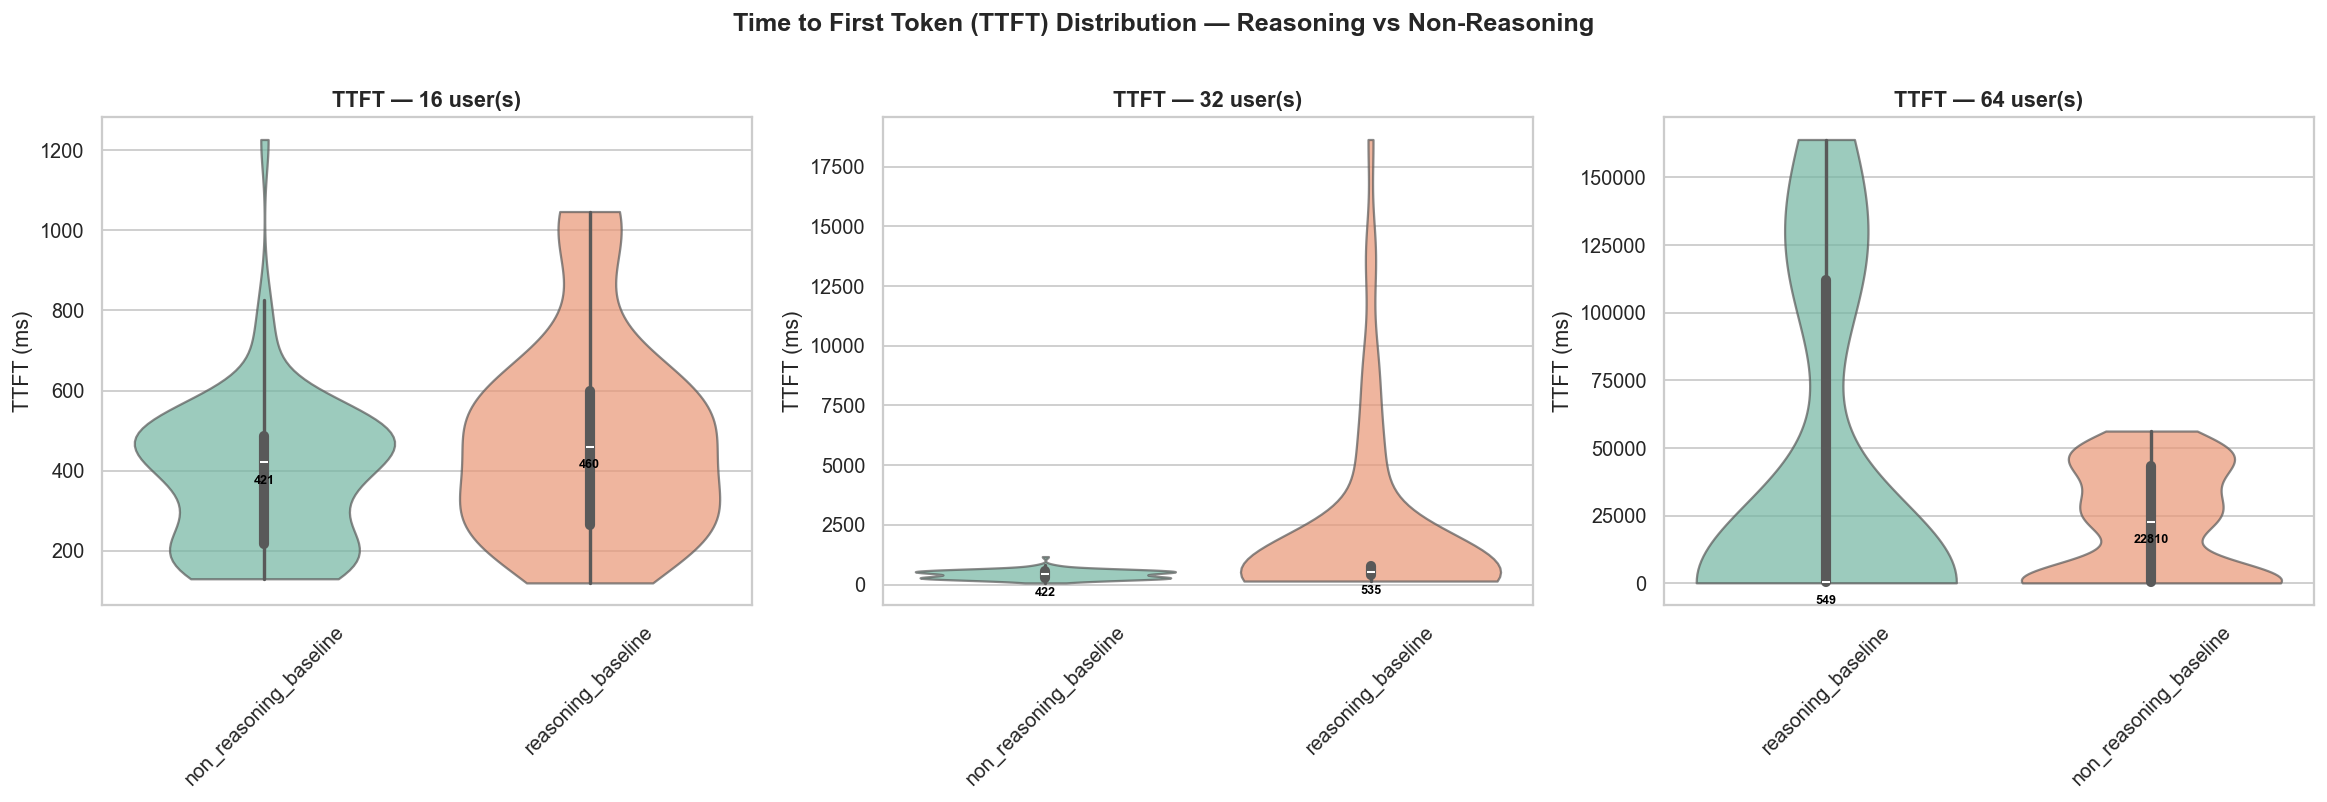

In [6]:
# ─── TTFT distribution — violin + box by experiment, faceted by concurrency ───
user_levels = sorted(r1['users'].unique())
n_u = len(user_levels)

fig, axes = plt.subplots(1, n_u, figsize=(6 * n_u, 6), sharey=False)
if n_u == 1:
    axes = [axes]

for ax, u in zip(axes, user_levels):
    sub = r1[r1['users'] == u]
    order = sub.groupby('experiment')['ttft_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='experiment', y='ttft_ms', order=order,
                   inner='box', cut=0, ax=ax, palette='Set2', alpha=0.7)
    ax.set_title(f'TTFT — {u} user(s)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('TTFT (ms)')
    ax.tick_params(axis='x', rotation=45)
    for i, exp in enumerate(order):
        med = sub[sub['experiment'] == exp]['ttft_ms'].median()
        ax.annotate(f'{med:.0f}', (i, med), textcoords='offset points',
                    xytext=(0, -12), ha='center', fontsize=7, color='black', fontweight='bold')

plt.suptitle('Time to First Token (TTFT) Distribution — Reasoning vs Non-Reasoning', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(run1_dir / 'ttft_violin.png', bbox_inches='tight')
plt.show()

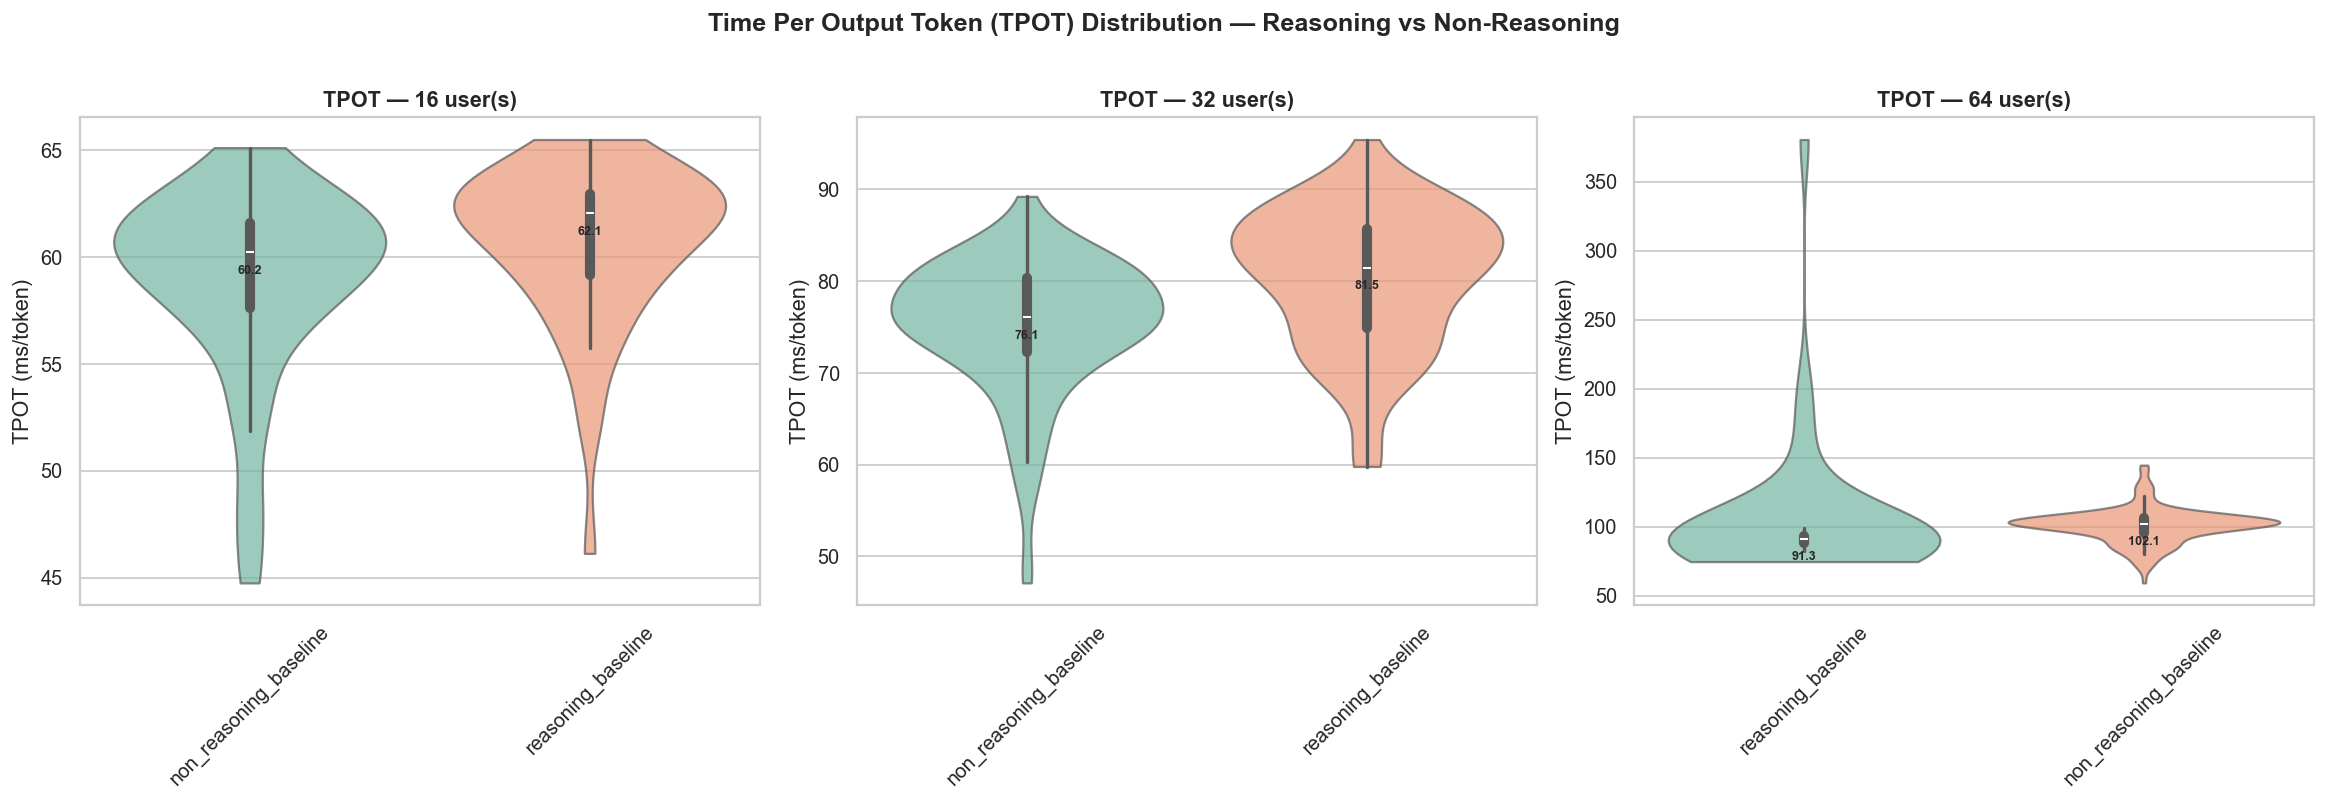

In [7]:
# ─── TPOT distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_u, figsize=(6 * n_u, 6), sharey=False)
if n_u == 1:
    axes = [axes]

for ax, u in zip(axes, user_levels):
    sub = r1[r1['users'] == u]
    order = sub.groupby('experiment')['tpot_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='experiment', y='tpot_ms', order=order,
                   inner='box', cut=0, ax=ax, palette='Set2', alpha=0.7)
    ax.set_title(f'TPOT — {u} user(s)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('TPOT (ms/token)')
    ax.tick_params(axis='x', rotation=45)
    for i, exp in enumerate(order):
        med = sub[sub['experiment'] == exp]['tpot_ms'].median()
        ax.annotate(f'{med:.1f}', (i, med), textcoords='offset points',
                    xytext=(0, -12), ha='center', fontsize=7, fontweight='bold')

plt.suptitle('Time Per Output Token (TPOT) Distribution — Reasoning vs Non-Reasoning', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(run1_dir / 'tpot_violin.png', bbox_inches='tight')
plt.show()

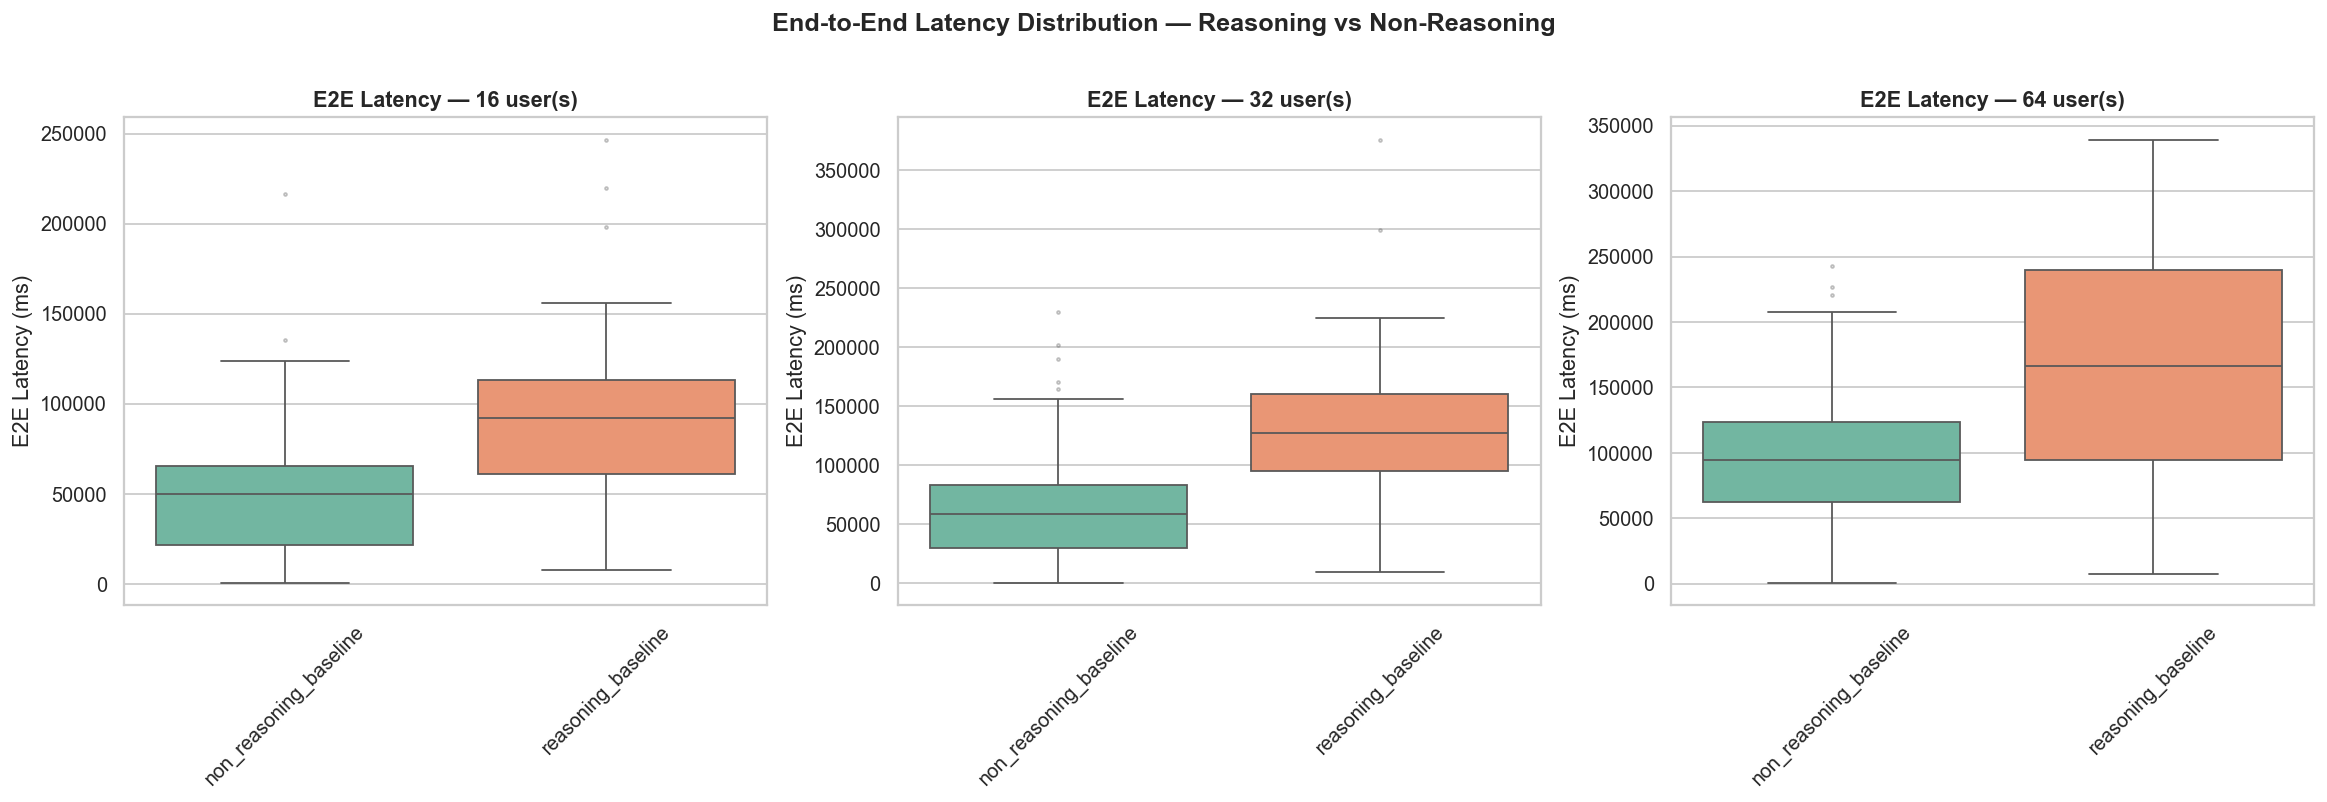

In [8]:
# ─── E2E Latency distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_u, figsize=(6 * n_u, 6), sharey=False)
if n_u == 1:
    axes = [axes]

for ax, u in zip(axes, user_levels):
    sub = r1[r1['users'] == u]
    order = sub.groupby('experiment')['e2e_ms'].median().sort_values().index
    sns.boxplot(data=sub, x='experiment', y='e2e_ms', order=order,
                ax=ax, palette='Set2', flierprops=dict(marker='.', markersize=3, alpha=0.4))
    ax.set_title(f'E2E Latency — {u} user(s)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('E2E Latency (ms)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('End-to-End Latency Distribution — Reasoning vs Non-Reasoning', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(run1_dir / 'e2e_boxplot.png', bbox_inches='tight')
plt.show()

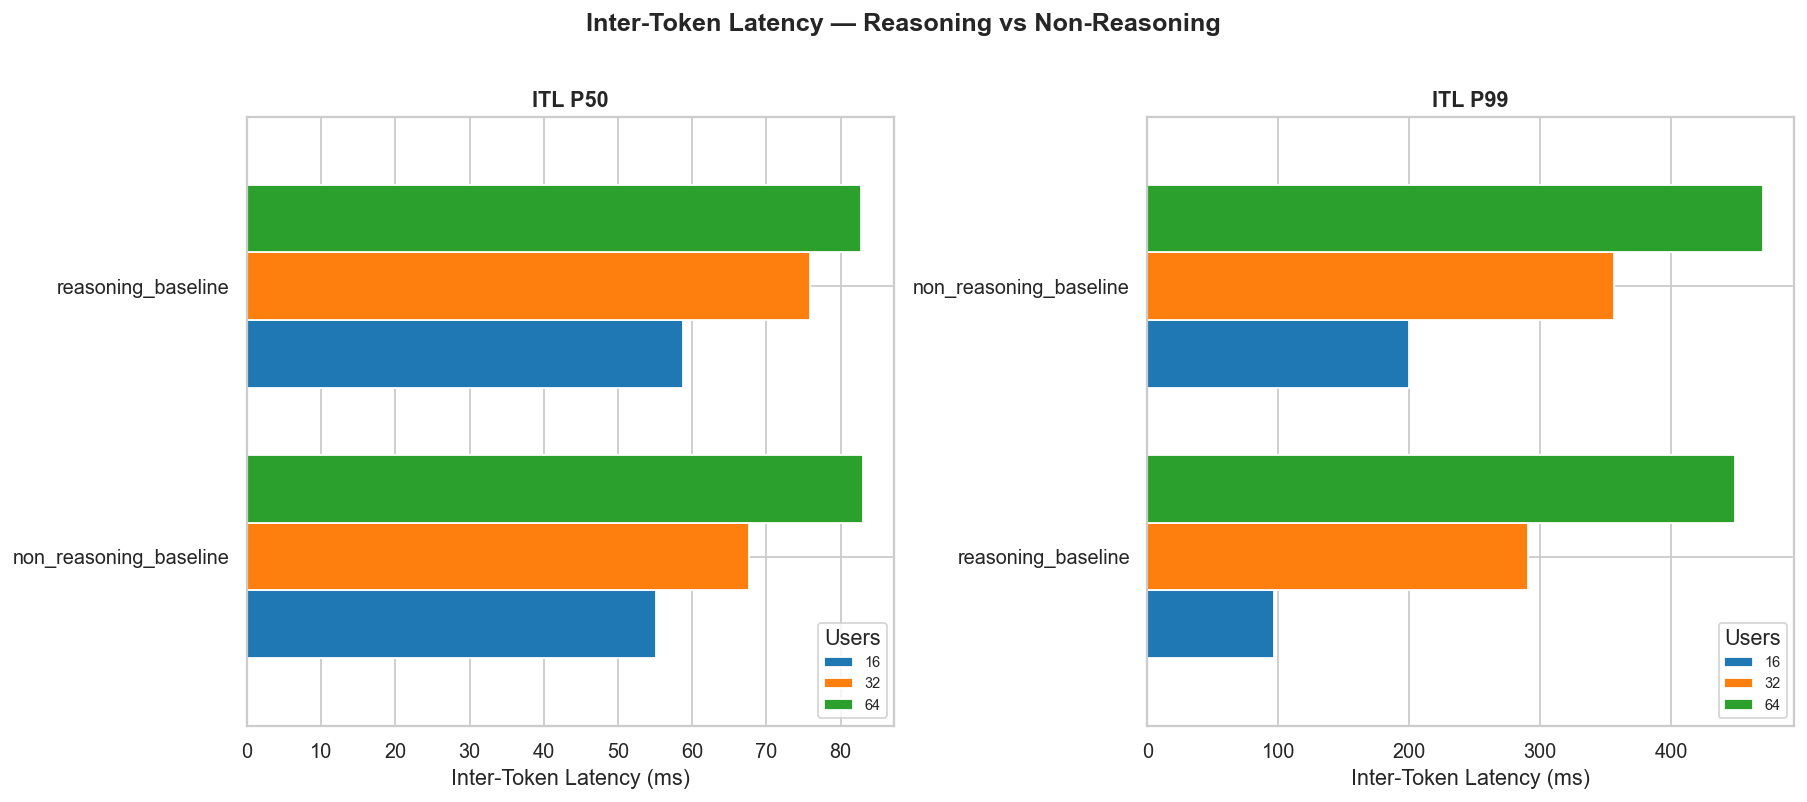

In [9]:
# ─── ITL (Inter-Token Latency) analysis — Run 1 ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

itl_agg = (
    r1.groupby(['experiment', 'users'])
    .agg(itl_p50=('itl_p50_ms', 'mean'), itl_p99=('itl_p99_ms', 'mean'))
    .reset_index()
)

for ax, metric, title in zip(axes, ['itl_p50', 'itl_p99'], ['ITL P50', 'ITL P99']):
    pivot = itl_agg.pivot(index='experiment', columns='users', values=metric)
    pivot = pivot.reindex(pivot.mean(axis=1).sort_values().index)
    pivot.plot(kind='barh', ax=ax, width=0.75)
    ax.set_xlabel('Inter-Token Latency (ms)')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('')
    ax.legend(title='Users', fontsize=8)

plt.suptitle('Inter-Token Latency — Reasoning vs Non-Reasoning', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(run1_dir / 'itl_analysis.png', bbox_inches='tight')
plt.show()

/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_44289/2240246172.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pareto1 = r1.groupby(['experiment', 'users']).apply(compute_throughput).reset_index()


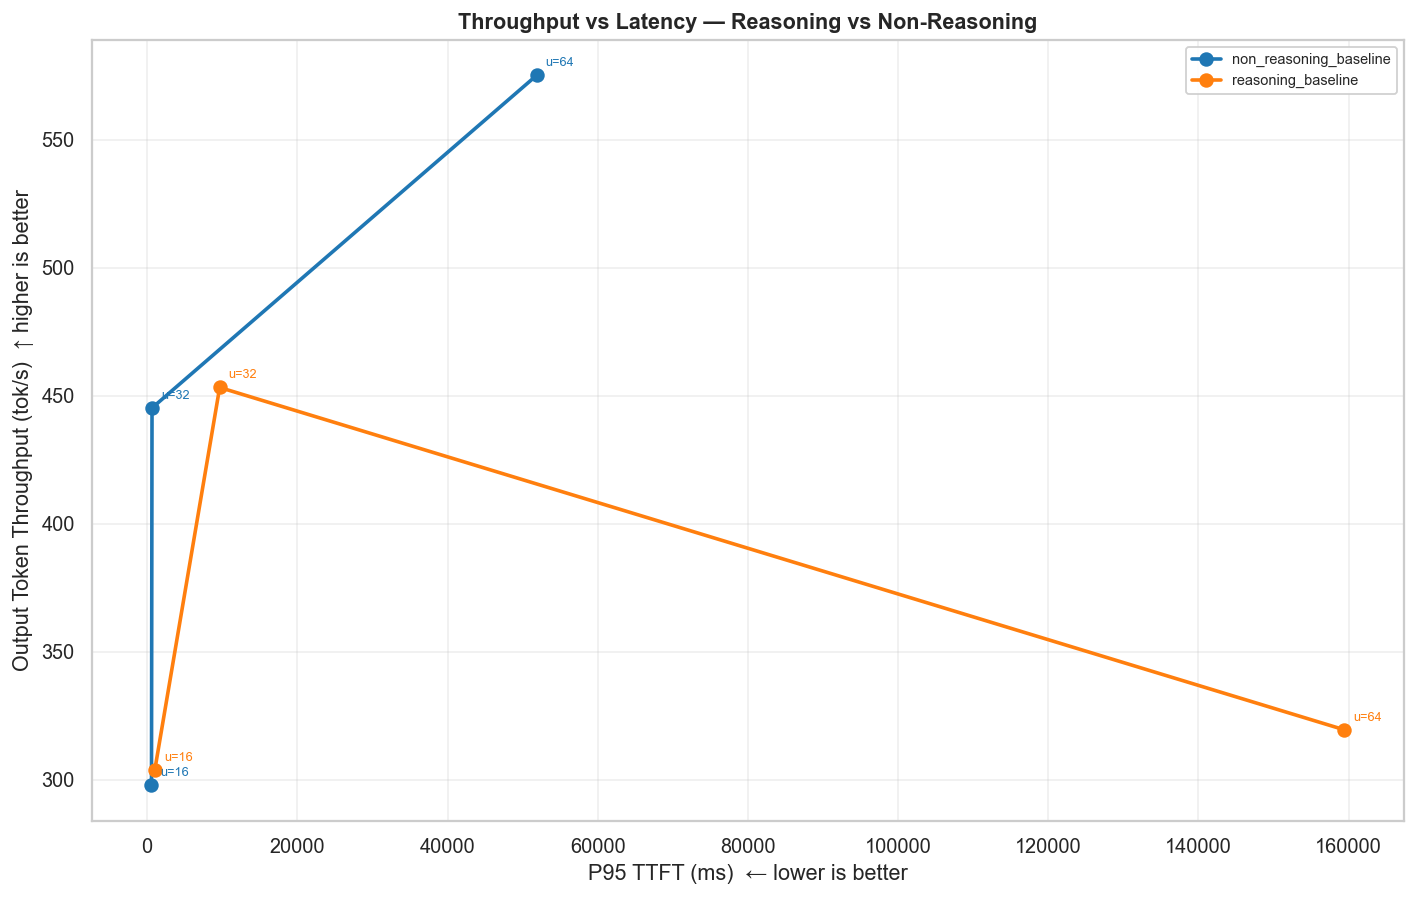

In [10]:
# ─── Throughput vs P95 TTFT — Pareto frontier (Run 1) ─────────────────────────
def compute_throughput(grp):
    total_tokens = grp['output_tokens'].sum()
    duration_s = grp['timestamp'].max() - grp['timestamp'].min()
    if duration_s < 1:
        duration_s = 1
    return pd.Series({
        'token_throughput': total_tokens / duration_s,
        'ttft_p95': grp['ttft_ms'].quantile(0.95),
        'ttft_p50': grp['ttft_ms'].quantile(0.50),
    })

pareto1 = r1.groupby(['experiment', 'users']).apply(compute_throughput).reset_index()

fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette('tab10', pareto1['experiment'].nunique())

for exp, color in zip(sorted(pareto1['experiment'].unique()), palette):
    sub = pareto1[pareto1['experiment'] == exp].sort_values('users')
    ax.plot(sub['ttft_p95'], sub['token_throughput'],
            marker='o', label=exp, color=color, linewidth=2, markersize=7)
    for _, row in sub.iterrows():
        ax.annotate(f'u={int(row["users"])}', (row['ttft_p95'], row['token_throughput']),
                    textcoords='offset points', xytext=(5, 5), fontsize=7, color=color)

ax.set_xlabel('P95 TTFT (ms)  ← lower is better')
ax.set_ylabel('Output Token Throughput (tok/s)  ↑ higher is better')
ax.set_title('Throughput vs Latency — Reasoning vs Non-Reasoning', fontweight='bold')
ax.legend(loc='best', fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(run1_dir / 'pareto_frontier.png', bbox_inches='tight')
plt.show()

Percentage change vs reasoning_baseline (negative = improvement):


ValueError: Unknown format code 'f' for object of type 'str'

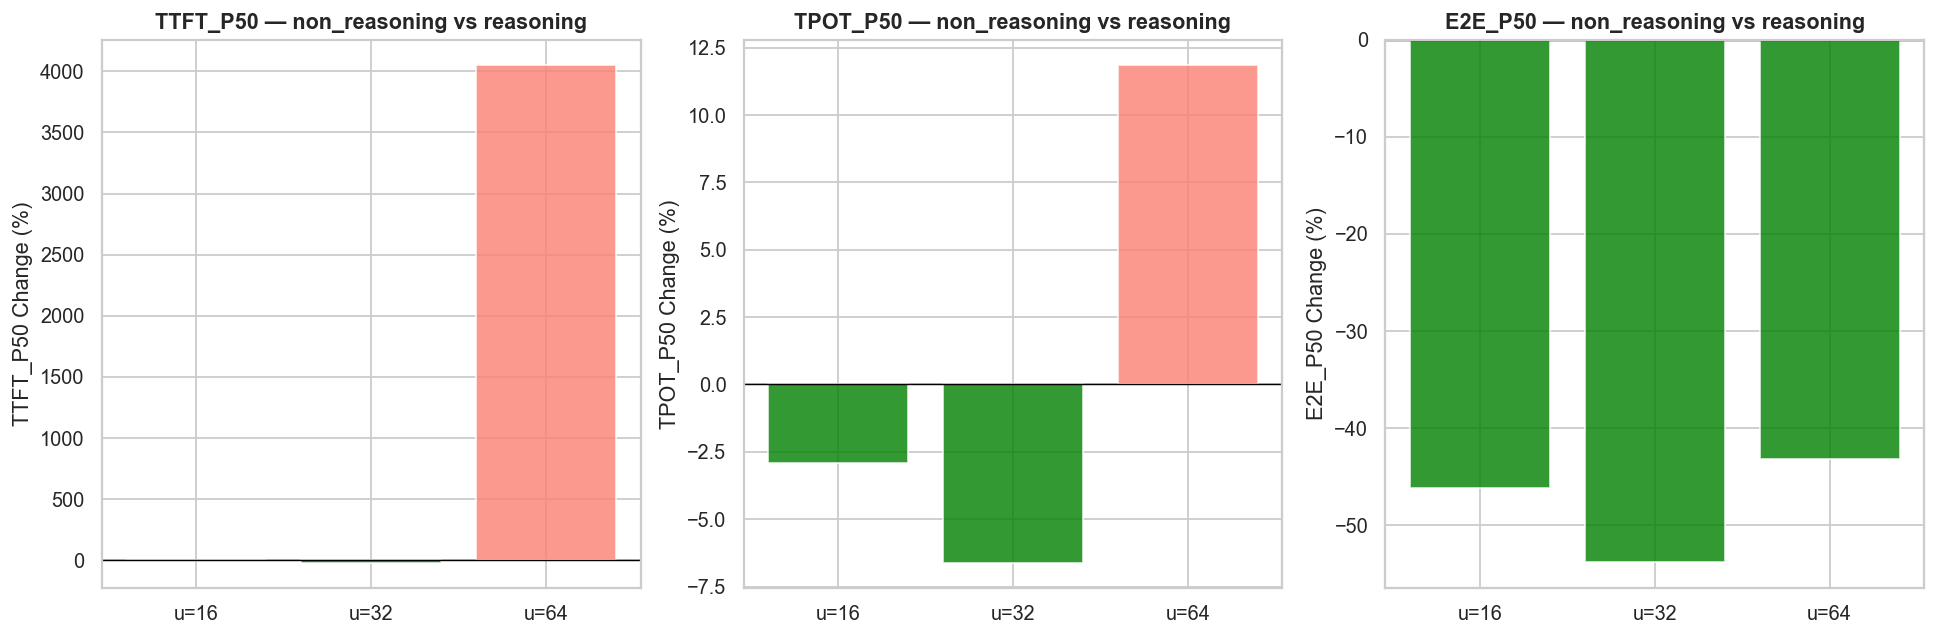

In [11]:
# ─── Reasoning vs Non-Reasoning: Percentage difference table ──────────────────
baseline_key = 'reasoning_baseline'
if baseline_key in r1['experiment'].unique():
    base = summary1_agg[summary1_agg['experiment'] == baseline_key].set_index('users')
    
    improvement_rows = []
    for exp in summary1_agg['experiment'].unique():
        if exp == baseline_key:
            continue
        comp = summary1_agg[summary1_agg['experiment'] == exp].set_index('users')
        for u in comp.index.intersection(base.index):
            b, c = base.loc[u], comp.loc[u]
            improvement_rows.append({
                'experiment': exp,
                'users': u,
                'ttft_p50_change_%': (c['ttft_p50'] - b['ttft_p50']) / b['ttft_p50'] * 100,
                'ttft_p99_change_%': (c['ttft_p99'] - b['ttft_p99']) / b['ttft_p99'] * 100,
                'tpot_p50_change_%': (c['tpot_p50'] - b['tpot_p50']) / b['tpot_p50'] * 100,
                'e2e_p50_change_%':  (c['e2e_p50'] - b['e2e_p50']) / b['e2e_p50'] * 100,
            })
    
    imp_df = pd.DataFrame(improvement_rows)
    print('Percentage change vs reasoning_baseline (negative = improvement):')
    display(imp_df.style.format('{:+.1f}%').map(
        lambda v: 'color: green' if isinstance(v, str) and v.startswith('-') else 'color: red' if isinstance(v, str) and v.startswith('+') else ''
    ))

    # Bar chart of key metric changes
    metrics_to_plot = ['ttft_p50_change_%', 'tpot_p50_change_%', 'e2e_p50_change_%']
    n_metrics = len(metrics_to_plot)
    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5))
    if n_metrics == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics_to_plot):
        label = metric.replace('_change_%', '').upper()
        colors = ['green' if v < 0 else 'salmon' for v in imp_df[metric]]
        ax.bar([f'u={u}' for u in imp_df['users']], imp_df[metric], color=colors, alpha=0.8)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_ylabel(f'{label} Change (%)')
        ax.set_title(f'{label} — non_reasoning vs reasoning', fontweight='bold')
    plt.tight_layout()
    plt.savefig(run1_dir / 'reasoning_improvement.png', bbox_inches='tight')
    plt.show()
else:
    print(f'⚠ No "{baseline_key}" experiment found in Run 1')


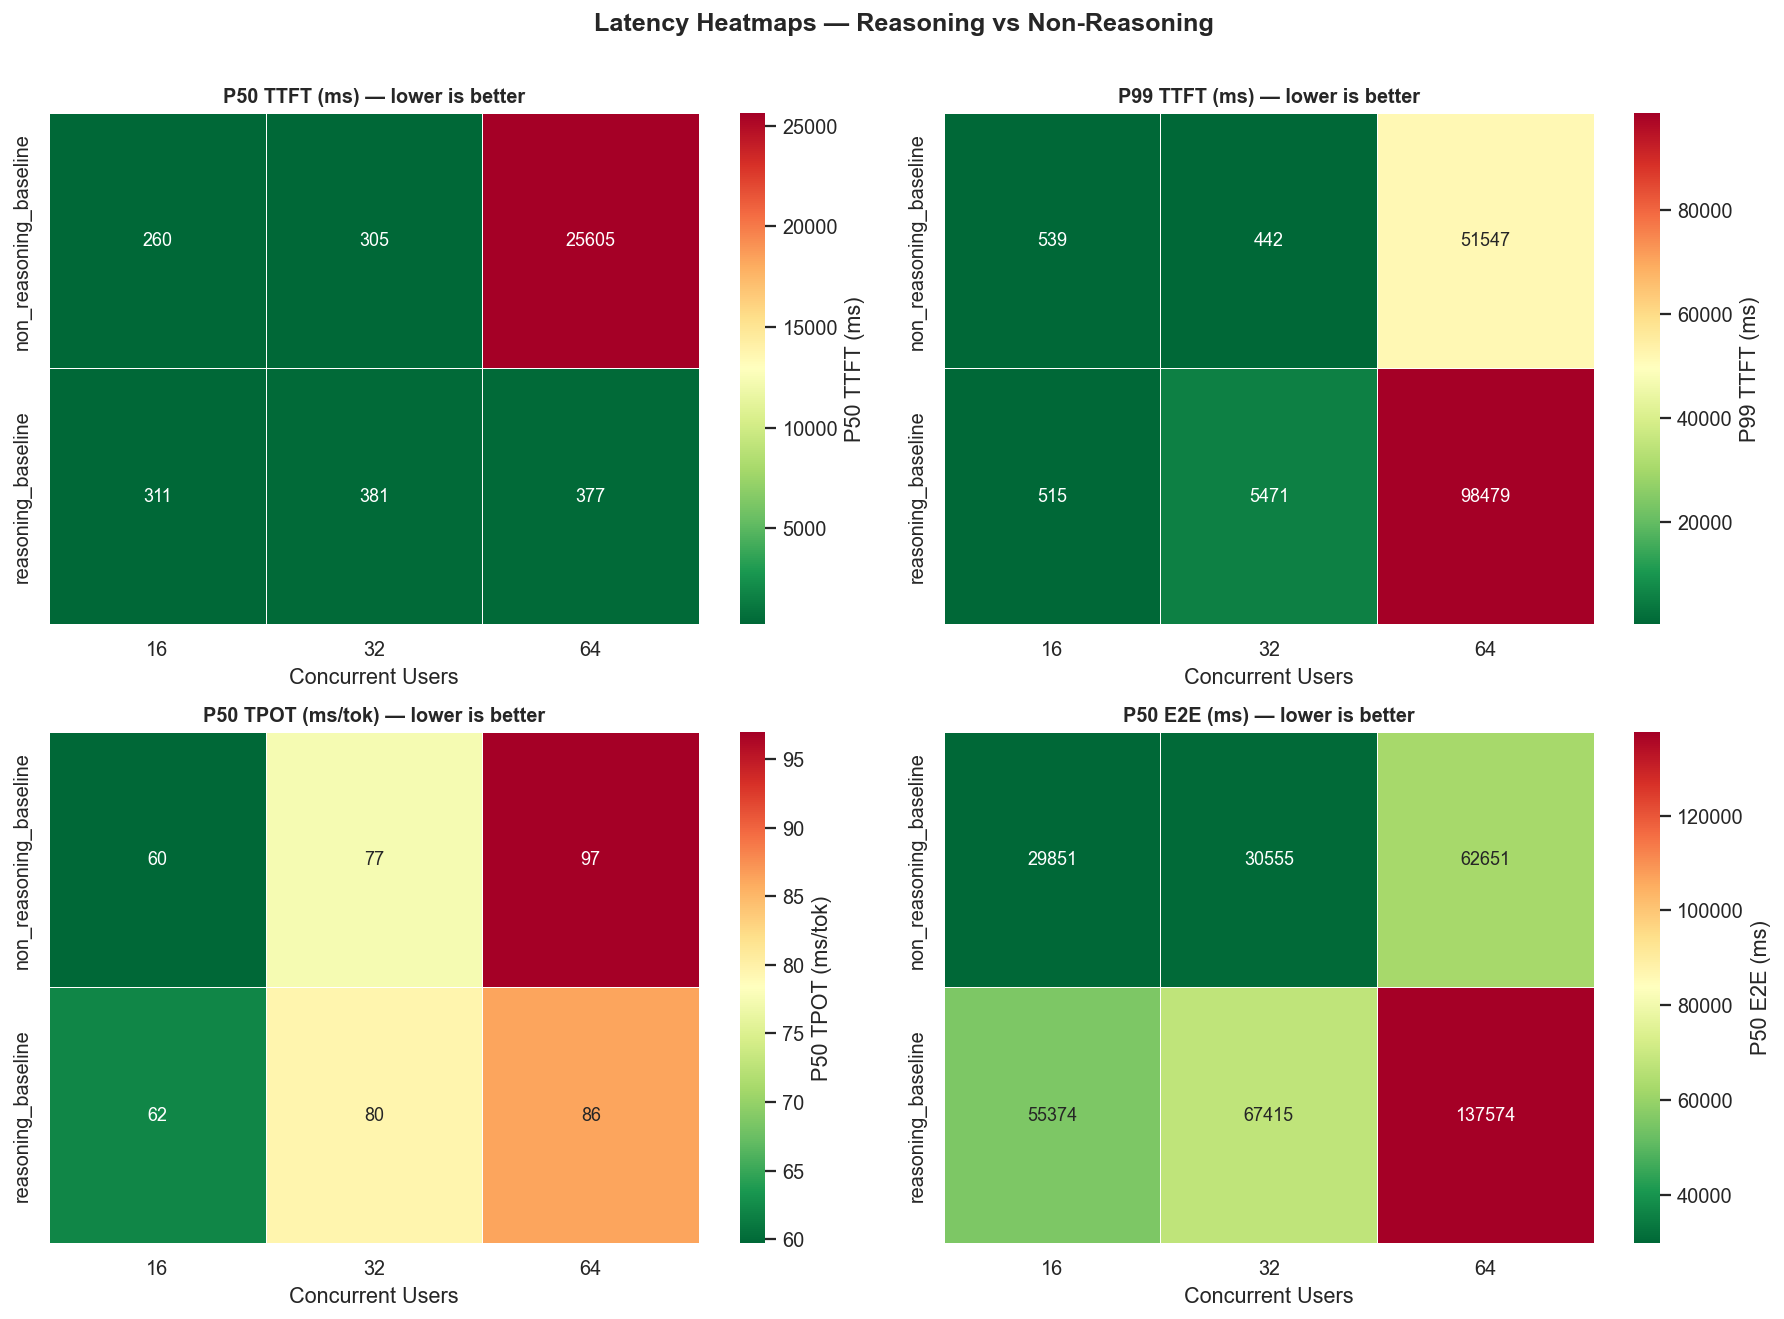

In [12]:
# ─── Heatmaps: TTFT P50, TTFT P99, TPOT P50, E2E P50 (Run 1) ────────────────
metrics_for_heatmap = [
    ('ttft_p50', 'P50 TTFT (ms)', 'RdYlGn_r'),
    ('ttft_p99', 'P99 TTFT (ms)', 'RdYlGn_r'),
    ('tpot_p50', 'P50 TPOT (ms/tok)', 'RdYlGn_r'),
    ('e2e_p50',  'P50 E2E (ms)', 'RdYlGn_r'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, title, cmap) in zip(axes.flat, metrics_for_heatmap):
    pivot = summary1.pivot_table(index='experiment', columns='users', values=col, aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap=cmap,
                linewidths=0.5, ax=ax, cbar_kws={'label': title})
    ax.set_title(title + ' — lower is better', fontweight='bold', fontsize=11)
    ax.set_xlabel('Concurrent Users')
    ax.set_ylabel('')

plt.suptitle('Latency Heatmaps — Reasoning vs Non-Reasoning', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(run1_dir / 'latency_heatmaps.png', bbox_inches='tight')
plt.show()

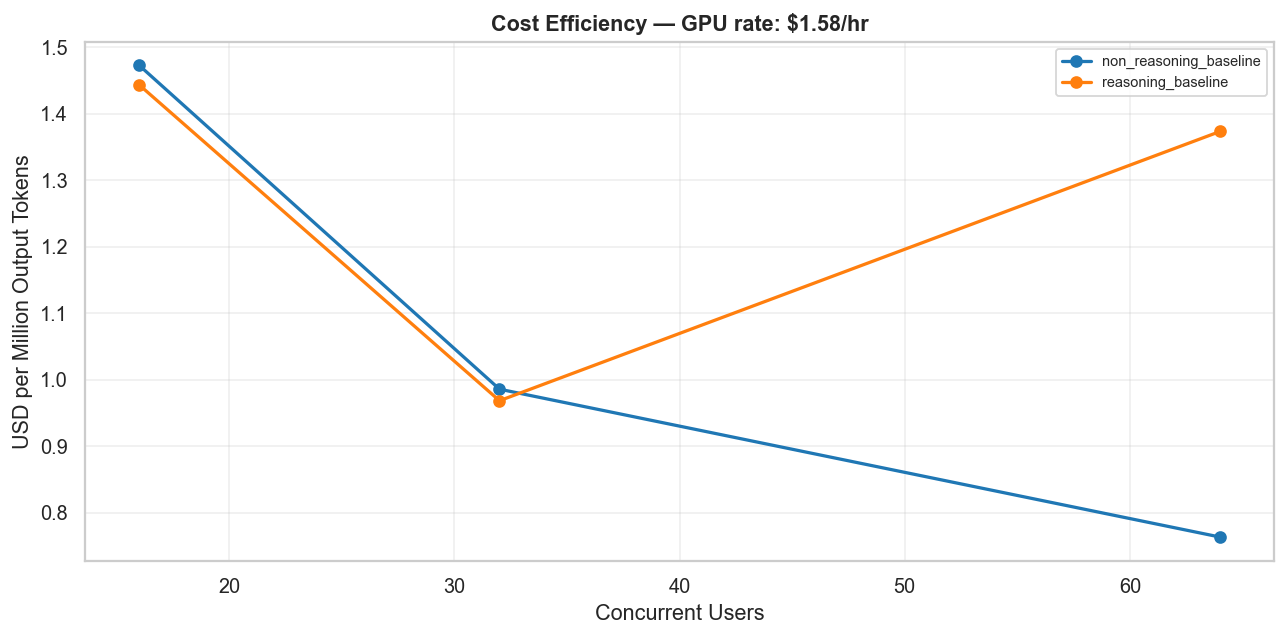

,experiment,users,total_tokens,duration_s,cost_per_M_tokens
0,non_reasoning_baseline,16,"68,238",229s,$1.47
1,non_reasoning_baseline,32,"106,137",238s,$0.99
2,non_reasoning_baseline,64,"138,617",241s,$0.76
3,reasoning_baseline,16,"70,429",232s,$1.44
4,reasoning_baseline,32,"103,532",228s,$0.97
5,reasoning_baseline,64,"51,441",161s,$1.37


In [13]:
# ─── Cost per million output tokens (Run 1) ───────────────────────────────────
cost_rows = []
for (exp, users), grp in r1.groupby(['experiment', 'users']):
    total_tokens = grp['output_tokens'].sum()
    duration_hr  = (grp['timestamp'].max() - grp['timestamp'].min()) / 3600
    if duration_hr < 1e-6 or total_tokens == 0:
        continue
    cost_per_m = (GPU_HOURLY_COST_USD * duration_hr) / (total_tokens / 1_000_000)
    cost_rows.append({
        'experiment': exp, 'users': users,
        'total_tokens': total_tokens,
        'duration_s': duration_hr * 3600,
        'cost_per_M_tokens': cost_per_m,
    })

cost_df1 = pd.DataFrame(cost_rows).sort_values(['experiment', 'users'])

fig, ax = plt.subplots(figsize=(10, 5))
for exp in sorted(cost_df1['experiment'].unique()):
    sub = cost_df1[cost_df1['experiment'] == exp]
    ax.plot(sub['users'], sub['cost_per_M_tokens'], marker='o', label=exp, linewidth=1.8)

ax.set_xlabel('Concurrent Users')
ax.set_ylabel('USD per Million Output Tokens')
ax.set_title(f'Cost Efficiency — GPU rate: ${GPU_HOURLY_COST_USD}/hr', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(run1_dir / 'cost_per_token.png', bbox_inches='tight')
plt.show()

display(cost_df1.style.format({'cost_per_M_tokens': '${:.2f}', 'duration_s': '{:.0f}s', 'total_tokens': '{:,}'}))

In [14]:
# ─── Export Run 1 summary to CSV ──────────────────────────────────────────────
summary1.to_csv(run1_dir / 'summary_run1.csv', index=False)
print(f'Run 1 summary saved to: {run1_dir / "summary_run1.csv"}')

Run 1 summary saved to: results/run_20260404_181323/summary_run1.csv


---
# Run 2 — KV Cache Dtype Comparison (auto vs fp8)

Compares the impact of KV cache data type on performance:
- `qwen3_kv_cache_auto` — default (auto) KV cache dtype
- `qwen3_kv_cache_fp8` — KV cache dtype set to fp8 (`--kv-cache-dtype fp8`)

FP8 KV cache reduces memory usage per token, potentially allowing more concurrent requests and higher throughput at the cost of slight precision loss.

Concurrency levels: 16, 32, 64, 128 users

In [15]:
# ─── Run 2: Percentile summary ────────────────────────────────────────────────
print(f'Run 2 summary ({len(summary2)} rows):')
display(summary2)

Run 2 summary (24 rows):


,experiment,users,category,n,ttft_mean,ttft_p50,ttft_p95,ttft_p99,tpot_mean,tpot_p50,tpot_p99,e2e_mean,e2e_p50,e2e_p99,itl_p50_mean,itl_p99_mean,output_tokens
0,qwen3_kv_cache_auto,16,long,116,573.6,374.7,741.9,7574.9,58.1,57.9,71.8,46338.9,42446.6,145423.7,53.4,179.4,92185
1,qwen3_kv_cache_auto,16,medium,14,235.9,173.2,513.4,571.7,56.8,58.1,60.1,21227.4,13937.2,53124.7,52.8,191.5,5172
2,qwen3_kv_cache_auto,16,short,1,166.9,166.9,166.9,166.9,65.9,65.9,65.9,759.9,759.9,759.9,53.9,102.9,10
3,qwen3_kv_cache_auto,32,long,156,486.3,452.7,757.0,2143.9,79.5,79.9,97.5,74527.4,67050.5,249276.3,72.1,343.1,145344
4,qwen3_kv_cache_auto,32,medium,8,332.3,259.6,618.3,622.5,79.5,80.4,100.0,19139.2,8719.4,48465.4,72.9,233.1,1853
5,qwen3_kv_cache_auto,32,short,2,231.2,231.2,236.1,236.5,86.7,86.7,87.4,3131.2,3131.2,3656.1,71.3,309.3,69
6,qwen3_kv_cache_auto,64,long,201,29462.0,30992.7,70355.9,79297.2,100.6,100.6,136.6,116397.8,111324.7,272732.7,84.4,485.2,176254
7,qwen3_kv_cache_auto,64,medium,30,26490.6,28867.1,57828.3,72503.9,114.7,101.4,337.9,70926.5,73322.7,172145.7,84.4,748.9,13092
8,qwen3_kv_cache_auto,64,short,3,16961.7,15153.3,33524.6,35157.6,134.7,117.4,220.5,36404.7,19382.4,87695.2,75.8,915.1,487
9,qwen3_kv_cache_auto,128,long,118,104529.0,142622.8,175672.8,179360.0,104.2,102.0,159.0,192149.7,189818.5,379432.0,85.6,525.9,101136


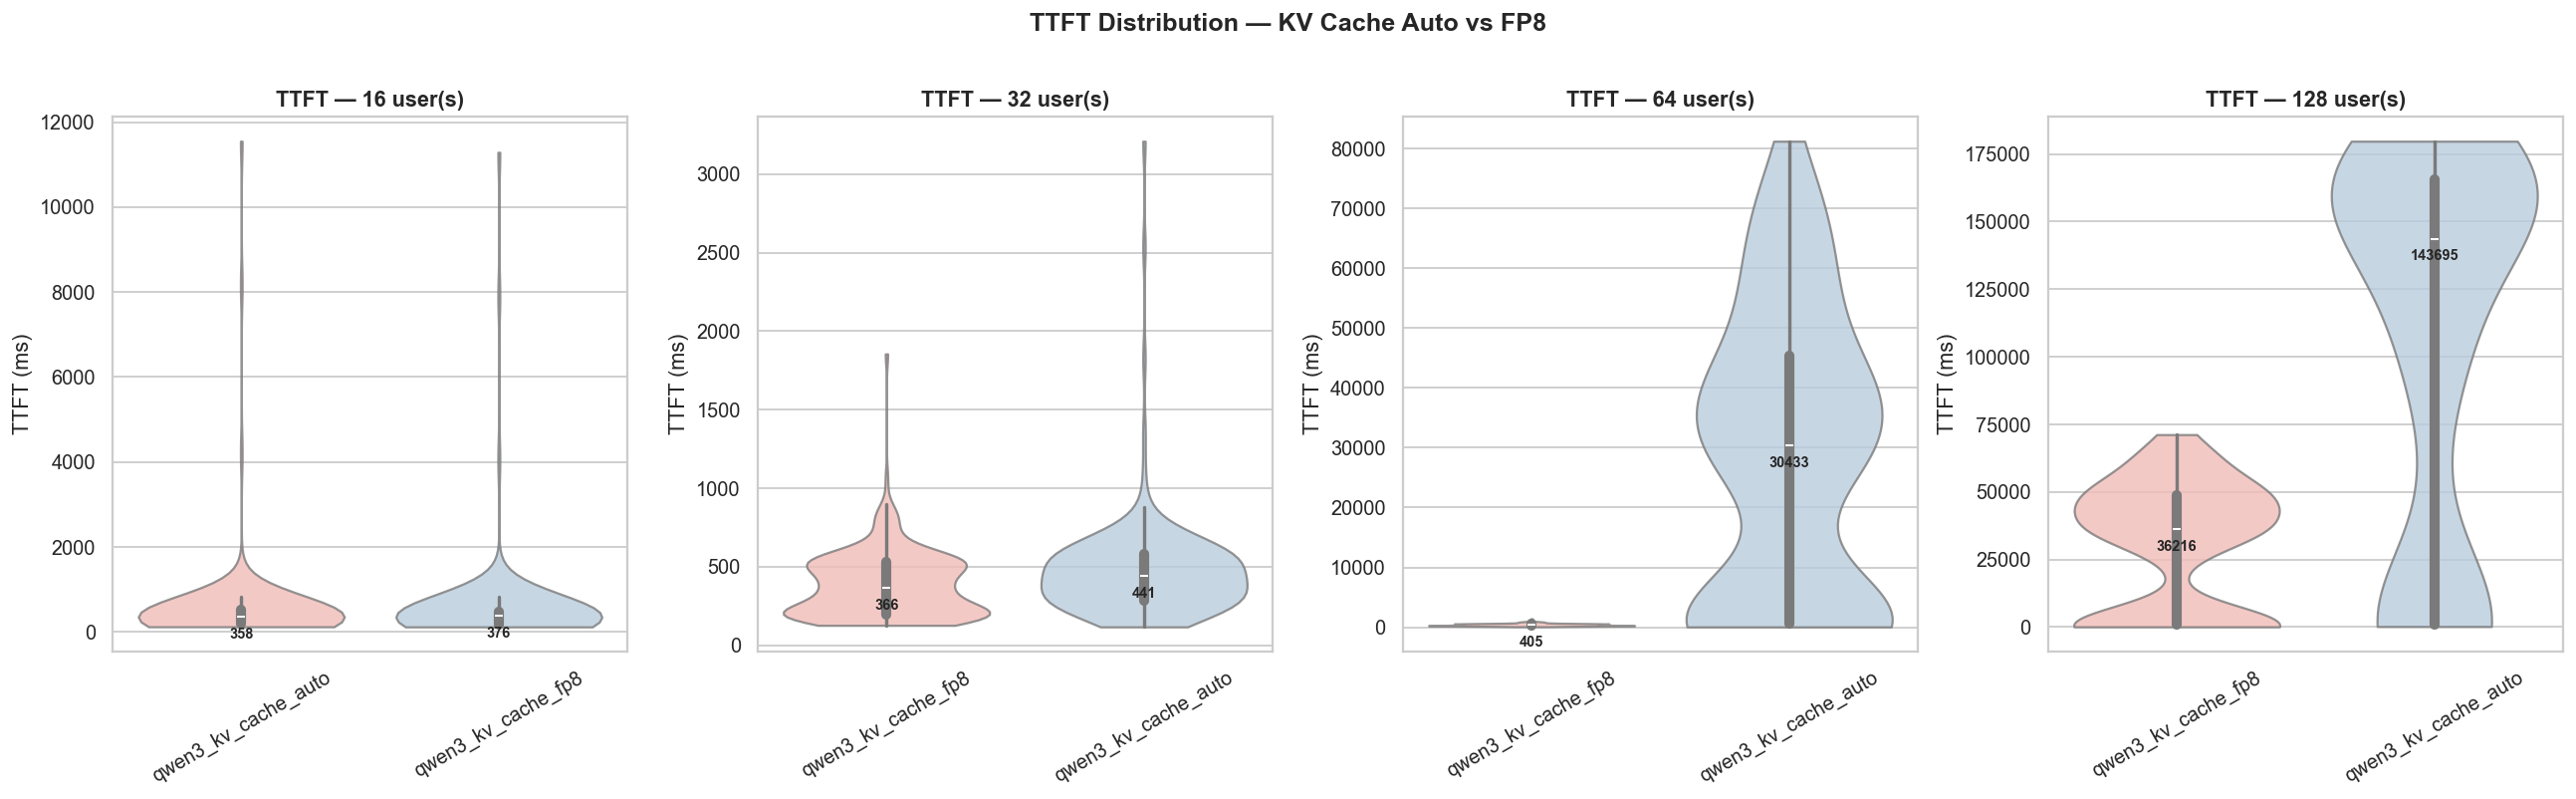

In [16]:
# ─── Run 2: TTFT distribution — violin ───────────────────────────────────────
user_levels_r2 = sorted(r2['users'].unique())
n_u2 = len(user_levels_r2)

fig, axes = plt.subplots(1, n_u2, figsize=(5 * n_u2, 6), sharey=False)
if n_u2 == 1:
    axes = [axes]

for ax, u in zip(axes, user_levels_r2):
    sub = r2[r2['users'] == u]
    order = sub.groupby('experiment')['ttft_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='experiment', y='ttft_ms', order=order,
                   inner='box', cut=0, ax=ax, palette='Pastel1', alpha=0.8)
    ax.set_title(f'TTFT — {u} user(s)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('TTFT (ms)')
    ax.tick_params(axis='x', rotation=30)
    for i, exp in enumerate(order):
        med = sub[sub['experiment'] == exp]['ttft_ms'].median()
        ax.annotate(f'{med:.0f}', (i, med), textcoords='offset points',
                    xytext=(0, -12), ha='center', fontsize=8, fontweight='bold')

plt.suptitle('TTFT Distribution — KV Cache Auto vs FP8', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(run2_dir / 'ttft_violin.png', bbox_inches='tight')
plt.show()

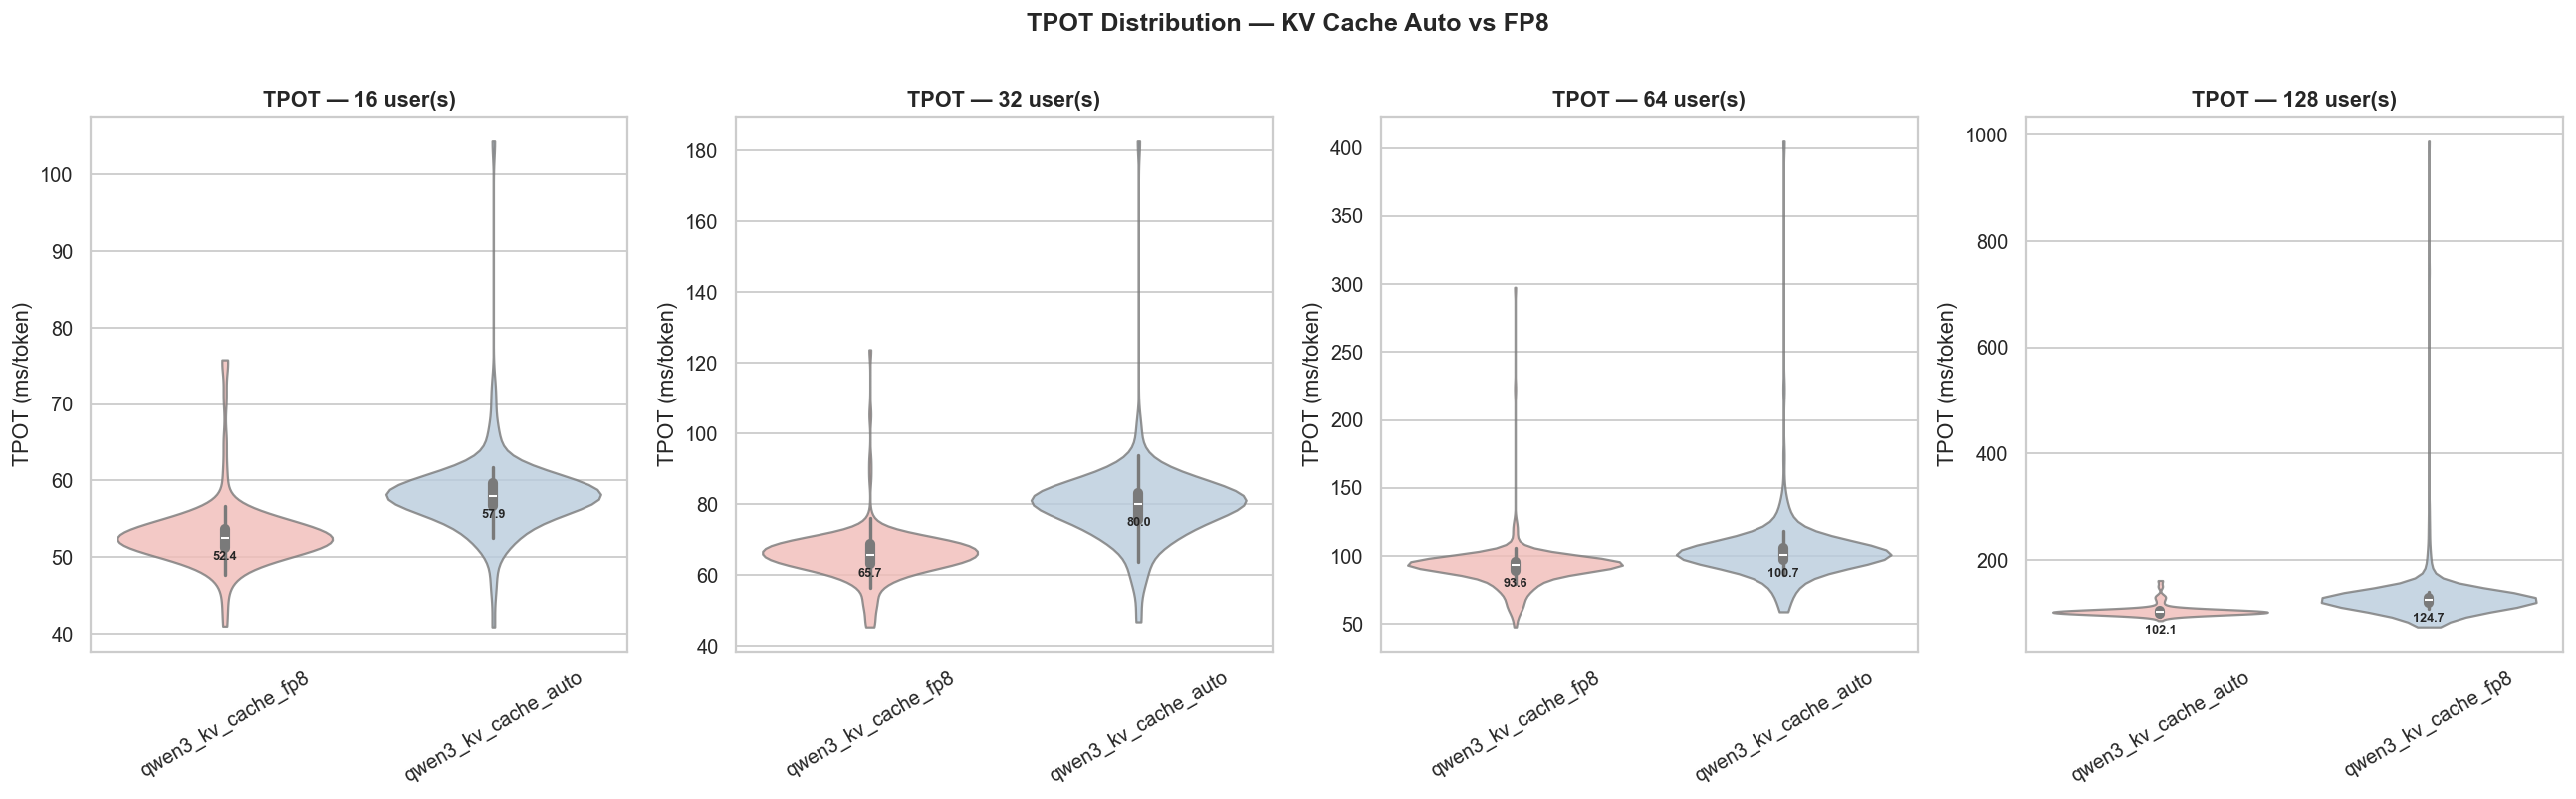

In [17]:
# ─── Run 2: TPOT distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, n_u2, figsize=(5 * n_u2, 6), sharey=False)
if n_u2 == 1:
    axes = [axes]

for ax, u in zip(axes, user_levels_r2):
    sub = r2[r2['users'] == u]
    order = sub.groupby('experiment')['tpot_ms'].median().sort_values().index
    sns.violinplot(data=sub, x='experiment', y='tpot_ms', order=order,
                   inner='box', cut=0, ax=ax, palette='Pastel1', alpha=0.8)
    ax.set_title(f'TPOT — {u} user(s)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('TPOT (ms/token)')
    ax.tick_params(axis='x', rotation=30)
    for i, exp in enumerate(order):
        med = sub[sub['experiment'] == exp]['tpot_ms'].median()
        ax.annotate(f'{med:.1f}', (i, med), textcoords='offset points',
                    xytext=(0, -12), ha='center', fontsize=7, fontweight='bold')

plt.suptitle('TPOT Distribution — KV Cache Auto vs FP8', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(run2_dir / 'tpot_violin.png', bbox_inches='tight')
plt.show()

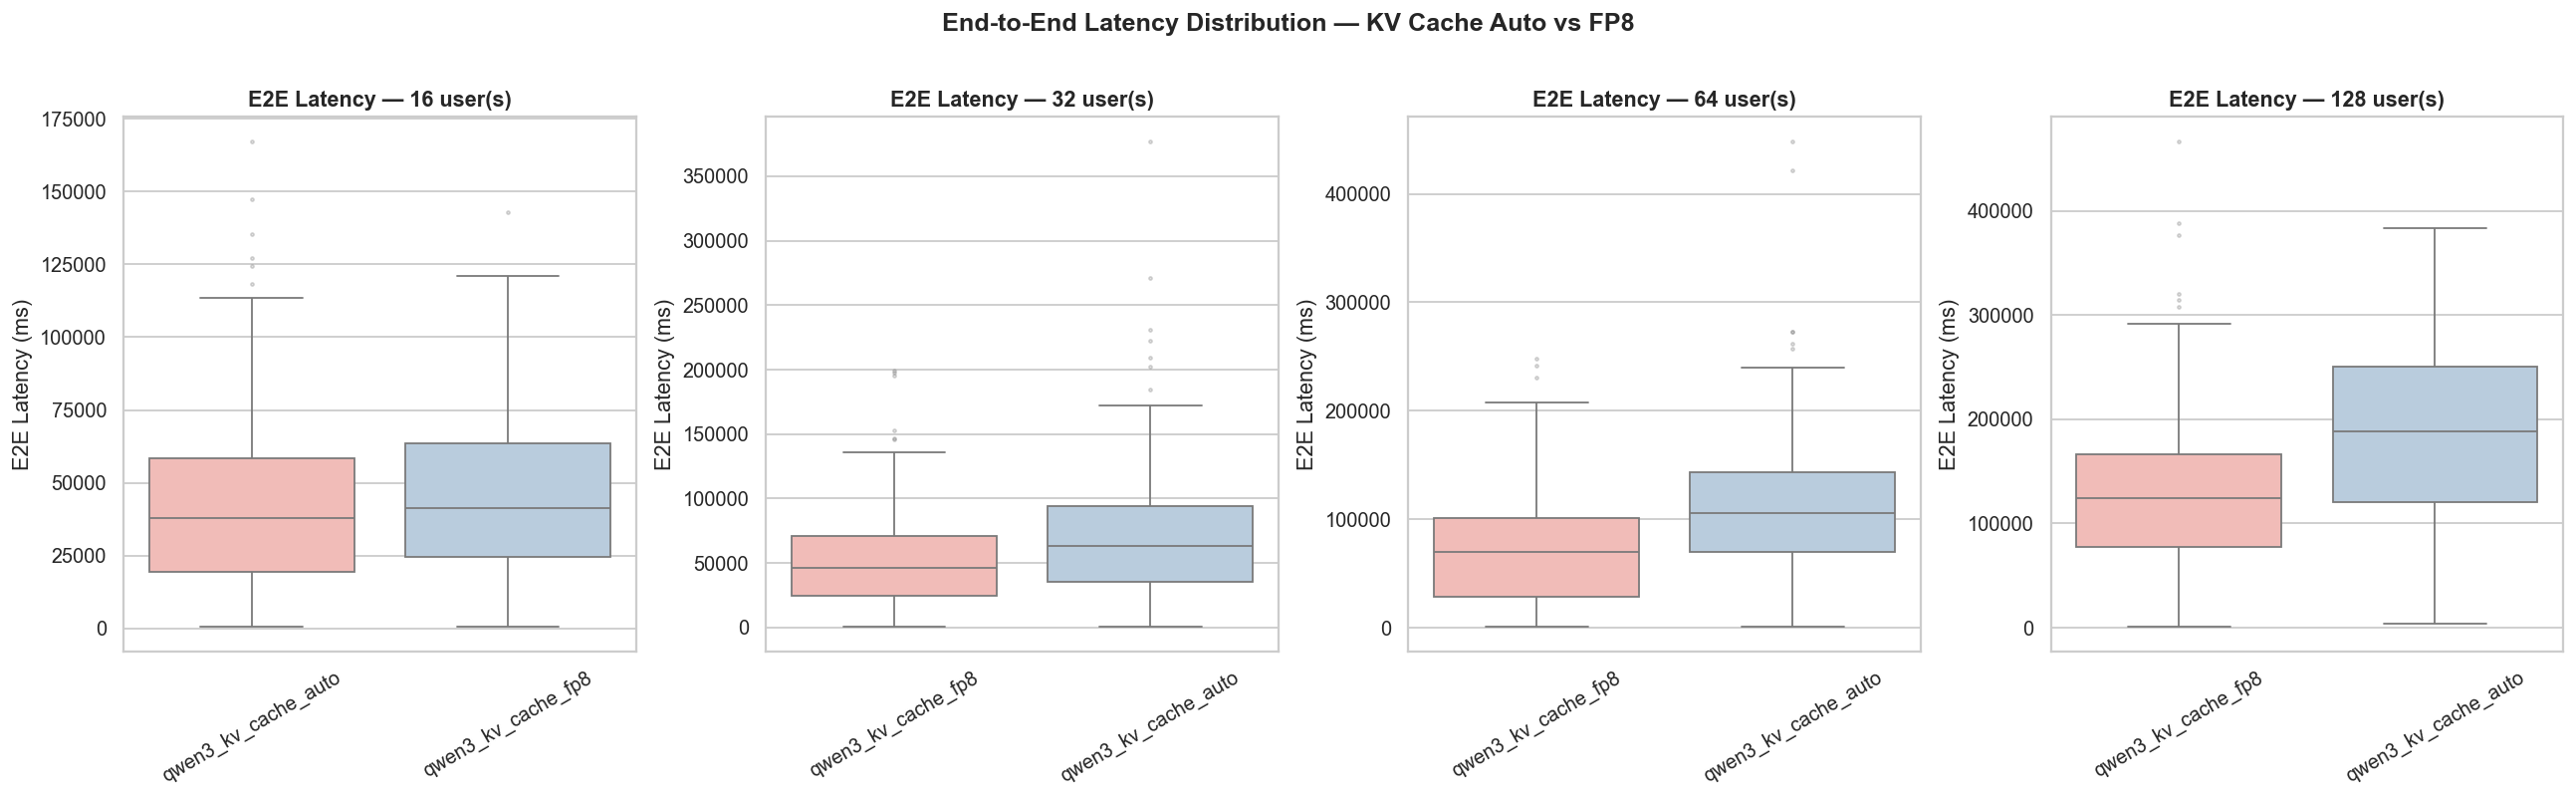

In [18]:
# ─── Run 2: E2E Latency distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, n_u2, figsize=(5 * n_u2, 6), sharey=False)
if n_u2 == 1:
    axes = [axes]

for ax, u in zip(axes, user_levels_r2):
    sub = r2[r2['users'] == u]
    order = sub.groupby('experiment')['e2e_ms'].median().sort_values().index
    sns.boxplot(data=sub, x='experiment', y='e2e_ms', order=order,
                ax=ax, palette='Pastel1', flierprops=dict(marker='.', markersize=3, alpha=0.4))
    ax.set_title(f'E2E Latency — {u} user(s)', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('E2E Latency (ms)')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('End-to-End Latency Distribution — KV Cache Auto vs FP8', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(run2_dir / 'e2e_boxplot.png', bbox_inches='tight')
plt.show()

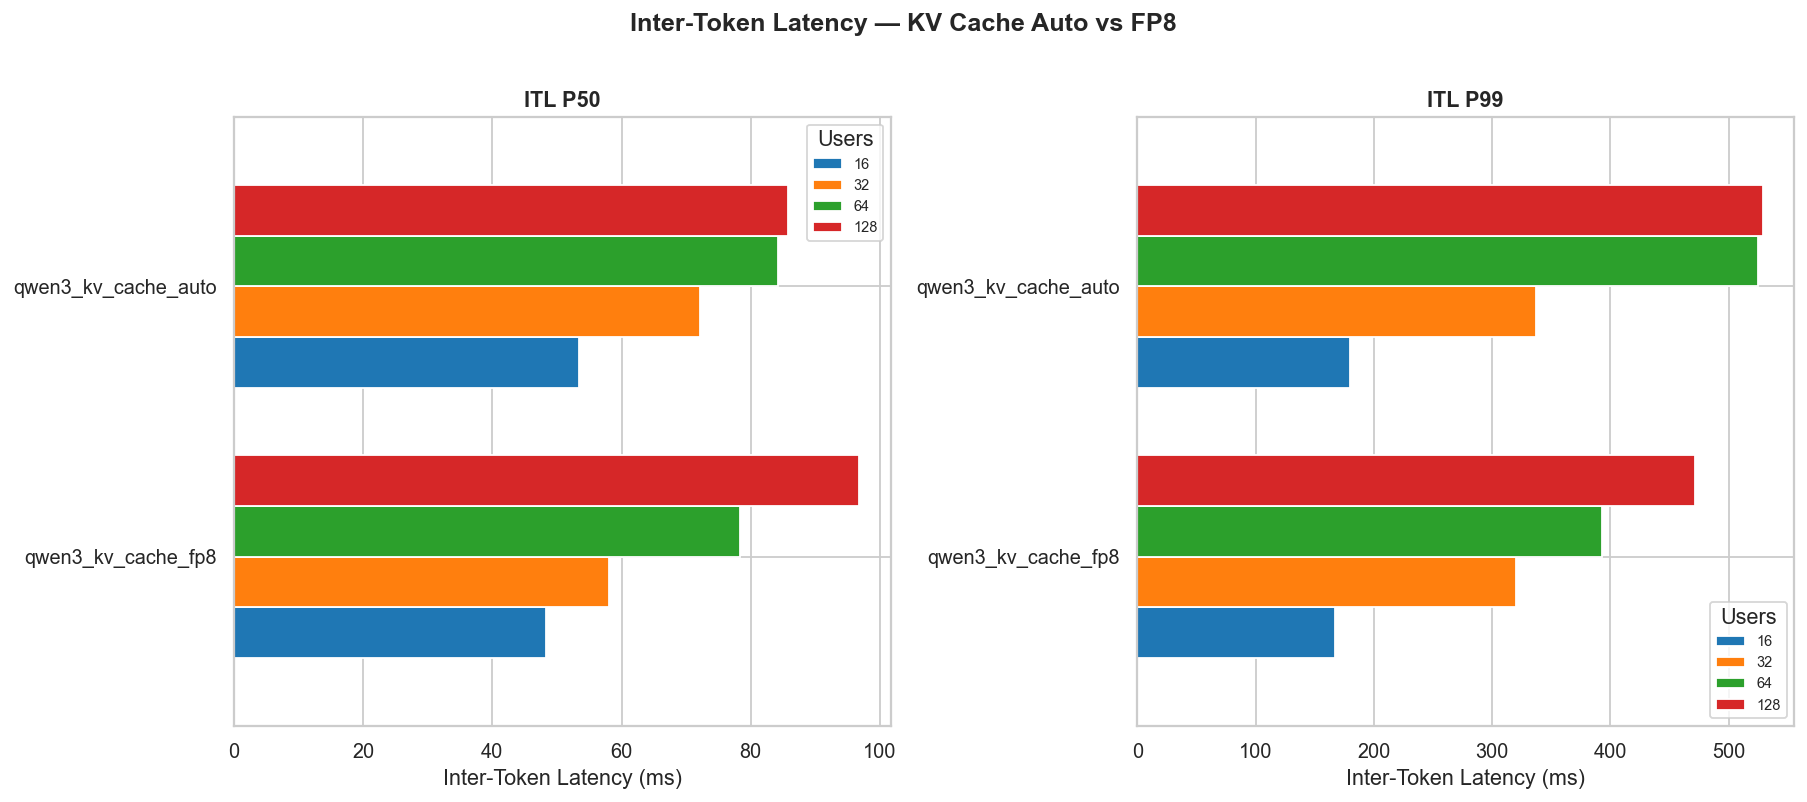

In [19]:
# ─── Run 2: ITL analysis ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

itl_agg2 = (
    r2.groupby(['experiment', 'users'])
    .agg(itl_p50=('itl_p50_ms', 'mean'), itl_p99=('itl_p99_ms', 'mean'))
    .reset_index()
)

for ax, metric, title in zip(axes, ['itl_p50', 'itl_p99'], ['ITL P50', 'ITL P99']):
    pivot = itl_agg2.pivot(index='experiment', columns='users', values=metric)
    pivot = pivot.reindex(pivot.mean(axis=1).sort_values().index)
    pivot.plot(kind='barh', ax=ax, width=0.75)
    ax.set_xlabel('Inter-Token Latency (ms)')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('')
    ax.legend(title='Users', fontsize=8)

plt.suptitle('Inter-Token Latency — KV Cache Auto vs FP8', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(run2_dir / 'itl_analysis.png', bbox_inches='tight')
plt.show()

/var/folders/y0/glglx_dn5nz0n_vpk90j3vl40000gn/T/ipykernel_44289/1137066677.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pareto2 = r2.groupby(['experiment', 'users']).apply(compute_throughput).reset_index()


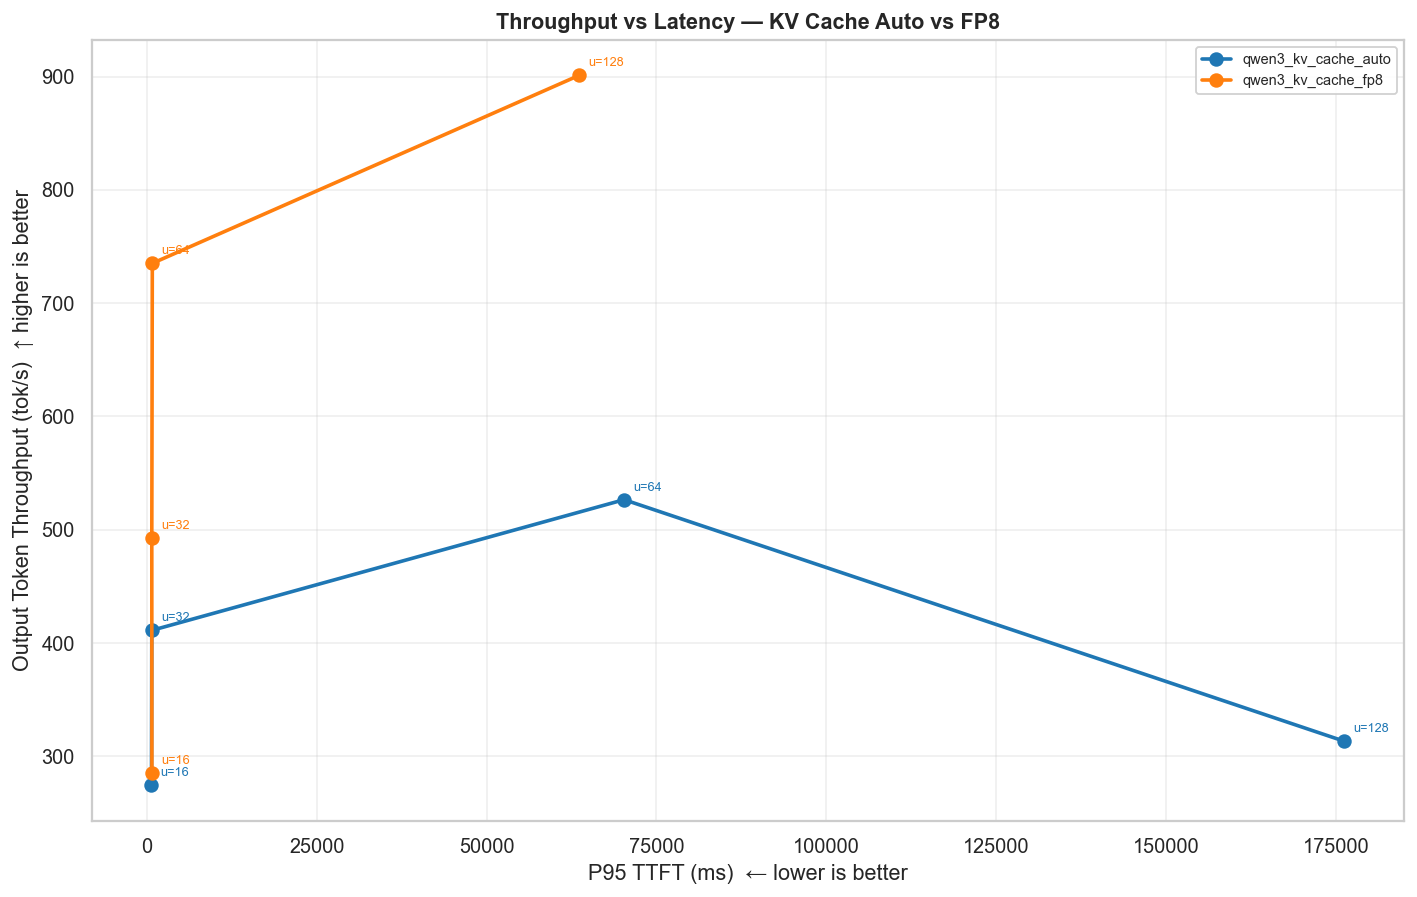

In [20]:
# ─── Run 2: Throughput vs P95 TTFT — Pareto frontier ──────────────────────────
pareto2 = r2.groupby(['experiment', 'users']).apply(compute_throughput).reset_index()

fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette('tab10', pareto2['experiment'].nunique())

for exp, color in zip(sorted(pareto2['experiment'].unique()), palette):
    sub = pareto2[pareto2['experiment'] == exp].sort_values('users')
    ax.plot(sub['ttft_p95'], sub['token_throughput'],
            marker='o', label=exp, color=color, linewidth=2, markersize=7)
    for _, row in sub.iterrows():
        ax.annotate(f'u={int(row["users"])}', (row['ttft_p95'], row['token_throughput']),
                    textcoords='offset points', xytext=(5, 5), fontsize=7, color=color)

ax.set_xlabel('P95 TTFT (ms)  ← lower is better')
ax.set_ylabel('Output Token Throughput (tok/s)  ↑ higher is better')
ax.set_title('Throughput vs Latency — KV Cache Auto vs FP8', fontweight='bold')
ax.legend(loc='best', fontsize=8, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(run2_dir / 'pareto_frontier.png', bbox_inches='tight')
plt.show()

Percentage change vs qwen3_kv_cache_auto (negative = improvement):


ValueError: Unknown format code 'f' for object of type 'str'

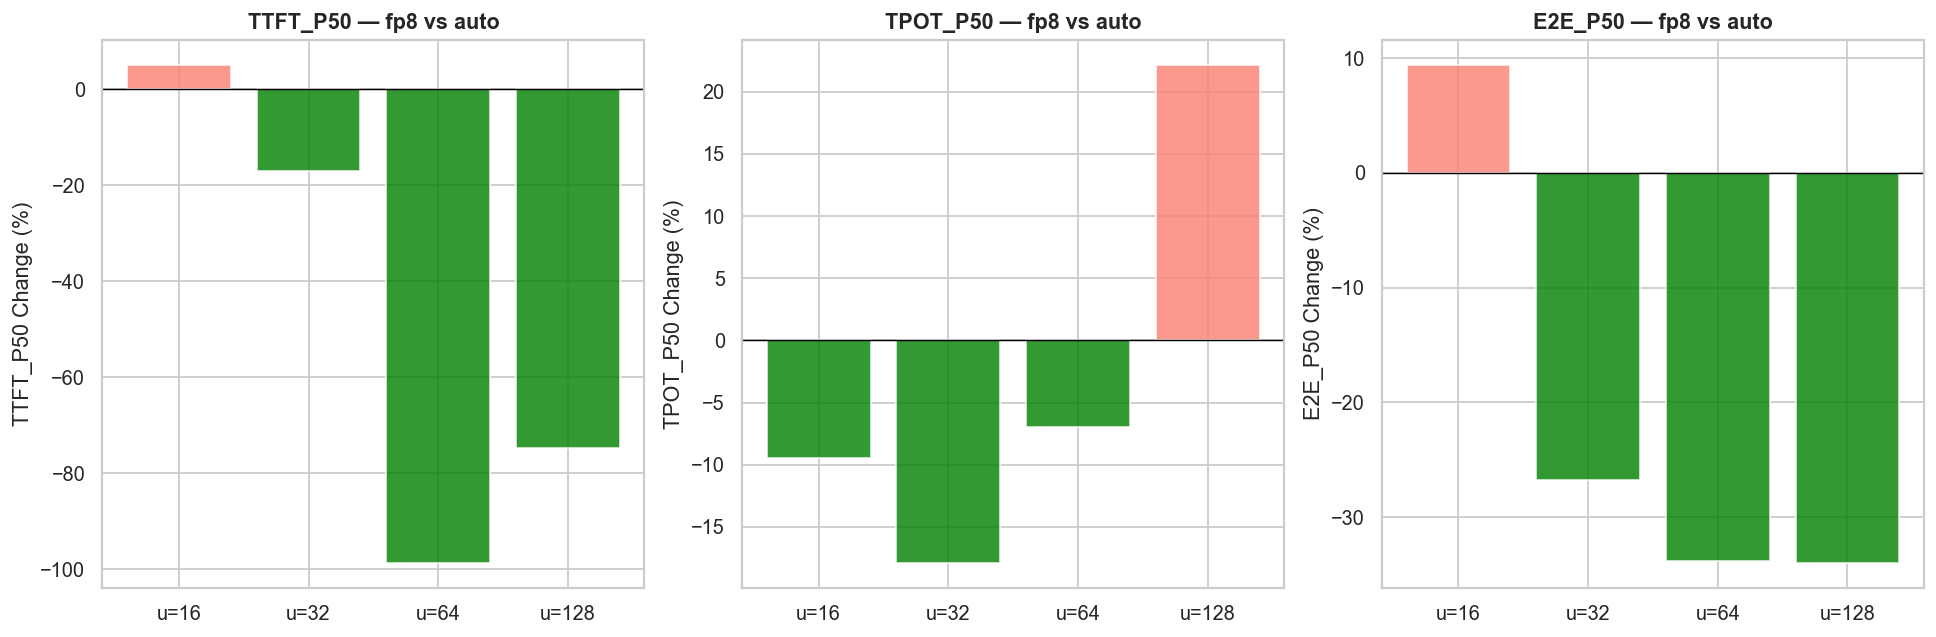

In [21]:
# ─── Run 2: KV Cache fp8 vs auto — percentage improvement ────────────────────
kv_baseline = 'qwen3_kv_cache_auto'
if kv_baseline in r2['experiment'].unique():
    base = summary2_agg[summary2_agg['experiment'] == kv_baseline].set_index('users')
    
    improvement_rows = []
    for exp in summary2_agg['experiment'].unique():
        if exp == kv_baseline:
            continue
        comp = summary2_agg[summary2_agg['experiment'] == exp].set_index('users')
        for u in comp.index.intersection(base.index):
            b, c = base.loc[u], comp.loc[u]
            improvement_rows.append({
                'experiment': exp,
                'users': u,
                'ttft_p50_change_%': (c['ttft_p50'] - b['ttft_p50']) / b['ttft_p50'] * 100,
                'ttft_p99_change_%': (c['ttft_p99'] - b['ttft_p99']) / b['ttft_p99'] * 100,
                'tpot_p50_change_%': (c['tpot_p50'] - b['tpot_p50']) / b['tpot_p50'] * 100,
                'e2e_p50_change_%':  (c['e2e_p50'] - b['e2e_p50']) / b['e2e_p50'] * 100,
            })
    
    imp_df2 = pd.DataFrame(improvement_rows)
    print('Percentage change vs qwen3_kv_cache_auto (negative = improvement):')
    display(imp_df2.style.format('{:+.1f}%').map(
        lambda v: 'color: green' if isinstance(v, str) and v.startswith('-') else 'color: red' if isinstance(v, str) and v.startswith('+') else ''
    ))

    # Bar chart
    metrics_to_plot = ['ttft_p50_change_%', 'tpot_p50_change_%', 'e2e_p50_change_%']
    n_metrics = len(metrics_to_plot)
    fig, axes = plt.subplots(1, n_metrics, figsize=(5 * n_metrics, 5))
    if n_metrics == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics_to_plot):
        label = metric.replace('_change_%', '').upper()
        colors = ['green' if v < 0 else 'salmon' for v in imp_df2[metric]]
        ax.bar([f'u={u}' for u in imp_df2['users']], imp_df2[metric], color=colors, alpha=0.8)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_ylabel(f'{label} Change (%)')
        ax.set_title(f'{label} — fp8 vs auto', fontweight='bold')
    plt.tight_layout()
    plt.savefig(run2_dir / 'kv_cache_improvement.png', bbox_inches='tight')
    plt.show()
else:
    print(f'⚠ No "{kv_baseline}" experiment found in Run 2')


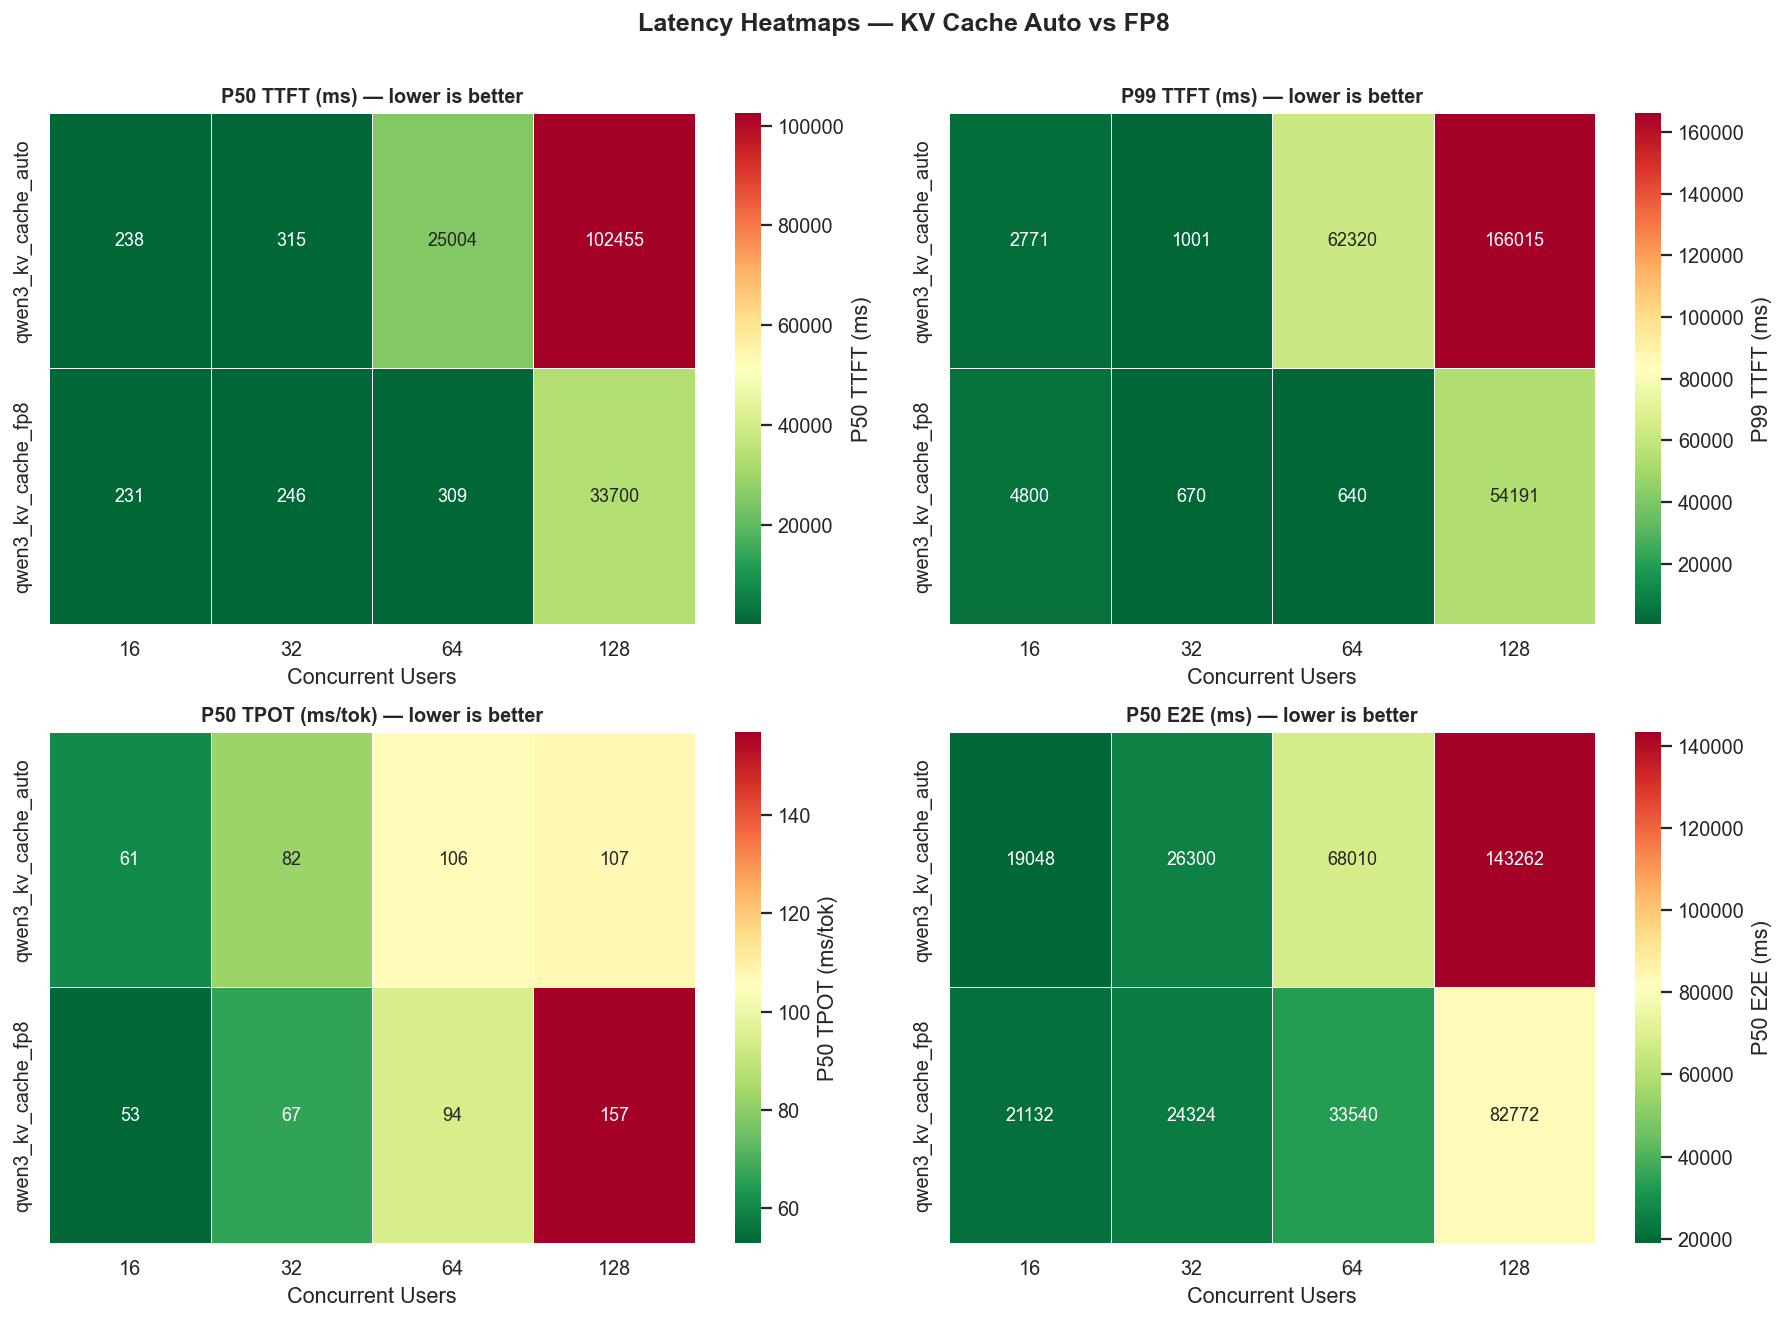

In [22]:
# ─── Run 2: Latency Heatmaps ──────────────────────────────────────────────────
metrics_for_heatmap = [
    ('ttft_p50', 'P50 TTFT (ms)', 'RdYlGn_r'),
    ('ttft_p99', 'P99 TTFT (ms)', 'RdYlGn_r'),
    ('tpot_p50', 'P50 TPOT (ms/tok)', 'RdYlGn_r'),
    ('e2e_p50',  'P50 E2E (ms)', 'RdYlGn_r'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, title, cmap) in zip(axes.flat, metrics_for_heatmap):
    pivot = summary2.pivot_table(index='experiment', columns='users', values=col, aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap=cmap,
                linewidths=0.5, ax=ax, cbar_kws={'label': title})
    ax.set_title(title + ' — lower is better', fontweight='bold', fontsize=11)
    ax.set_xlabel('Concurrent Users')
    ax.set_ylabel('')

plt.suptitle('Latency Heatmaps — KV Cache Auto vs FP8', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(run2_dir / 'latency_heatmaps.png', bbox_inches='tight')
plt.show()

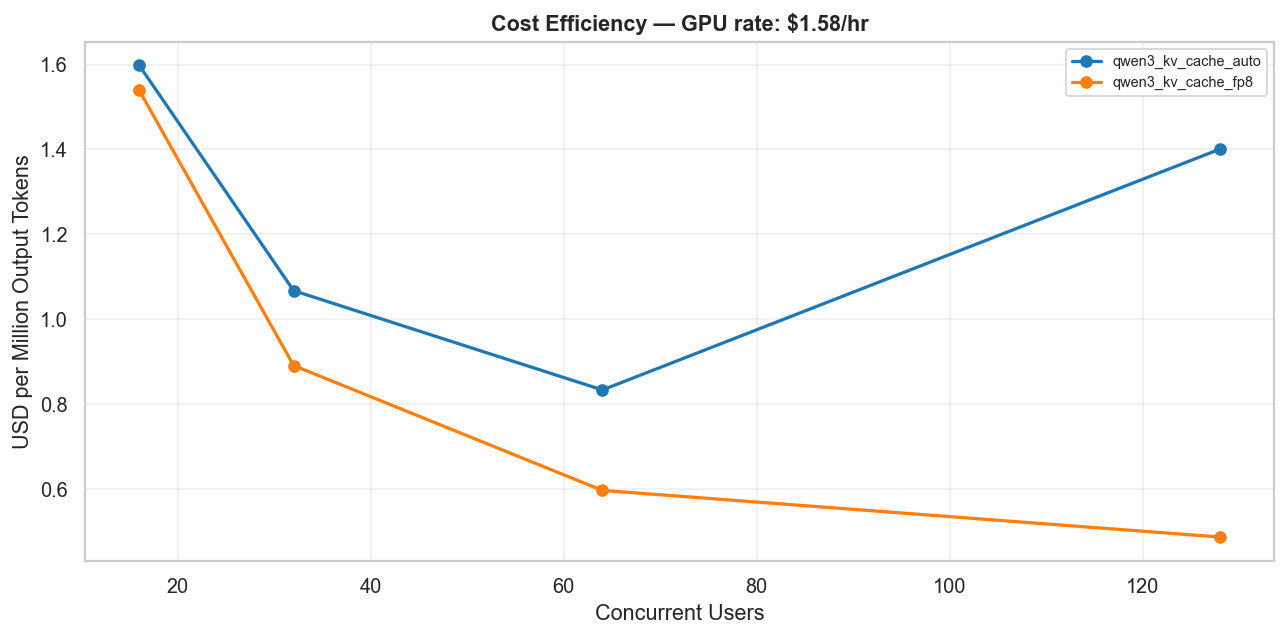

,experiment,users,total_tokens,duration_s,cost_per_M_tokens
0,qwen3_kv_cache_auto,16,"97,367",354s,$1.60
1,qwen3_kv_cache_auto,32,"147,266",358s,$1.07
2,qwen3_kv_cache_auto,64,"189,833",361s,$0.83
3,qwen3_kv_cache_auto,128,"106,870",341s,$1.40
4,qwen3_kv_cache_fp8,16,"101,555",356s,$1.54
5,qwen3_kv_cache_fp8,32,"176,191",358s,$0.89
6,qwen3_kv_cache_fp8,64,"264,479",360s,$0.60
7,qwen3_kv_cache_fp8,128,"323,947",360s,$0.49


In [23]:
# ─── Run 2: Cost per million output tokens ───────────────────────────────────
cost_rows = []
for (exp, users), grp in r2.groupby(['experiment', 'users']):
    total_tokens = grp['output_tokens'].sum()
    duration_hr  = (grp['timestamp'].max() - grp['timestamp'].min()) / 3600
    if duration_hr < 1e-6 or total_tokens == 0:
        continue
    cost_per_m = (GPU_HOURLY_COST_USD * duration_hr) / (total_tokens / 1_000_000)
    cost_rows.append({
        'experiment': exp, 'users': users,
        'total_tokens': total_tokens,
        'duration_s': duration_hr * 3600,
        'cost_per_M_tokens': cost_per_m,
    })

cost_df2 = pd.DataFrame(cost_rows).sort_values(['experiment', 'users'])

fig, ax = plt.subplots(figsize=(10, 5))
for exp in sorted(cost_df2['experiment'].unique()):
    sub = cost_df2[cost_df2['experiment'] == exp]
    ax.plot(sub['users'], sub['cost_per_M_tokens'], marker='o', label=exp, linewidth=1.8)

ax.set_xlabel('Concurrent Users')
ax.set_ylabel('USD per Million Output Tokens')
ax.set_title(f'Cost Efficiency — GPU rate: ${GPU_HOURLY_COST_USD}/hr', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(run2_dir / 'cost_per_token.png', bbox_inches='tight')
plt.show()

display(cost_df2.style.format({'cost_per_M_tokens': '${:.2f}', 'duration_s': '{:.0f}s', 'total_tokens': '{:,}'}))

In [24]:
# ─── Export Run 2 summary to CSV ──────────────────────────────────────────────
summary2.to_csv(run2_dir / 'summary_run2.csv', index=False)
print(f'Run 2 summary saved to: {run2_dir / "summary_run2.csv"}')

Run 2 summary saved to: results/run_20260405_005704/summary_run2.csv


Total failed requests across all runs: 7

Error breakdown:


,run,experiment,error_type,count
0,run1,reasoning_baseline,ConnectionError,2
1,run2,qwen3_kv_cache_auto,ConnectionError,5


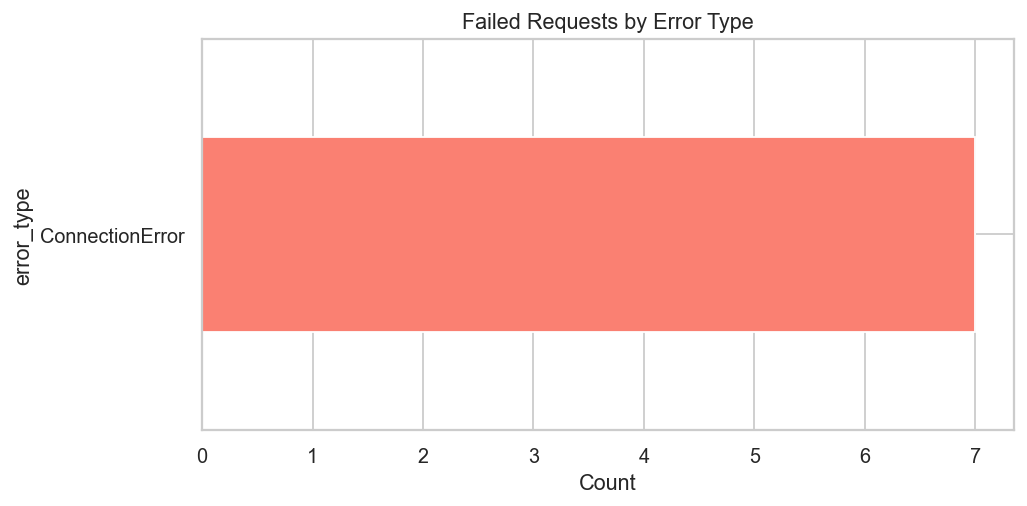

In [25]:
# ─── Error analysis (all runs) ────────────────────────────────────────────────
errors = df_all[df_all['success'] == False]
print(f'Total failed requests across all runs: {len(errors)}')

if not errors.empty:
    print('\nError breakdown:')
    display(errors.groupby(['run', 'experiment', 'error_type']).size().rename('count').reset_index())
    fig, ax = plt.subplots(figsize=(8, 4))
    errors.groupby('error_type').size().sort_values().plot(kind='barh', ax=ax, color='salmon')
    ax.set_title('Failed Requests by Error Type')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print('✅ No errors in any run — 100% success rate!')

---
# Server-Side Metrics (Prometheus)

The following cells analyze GPU utilization, KV cache usage, queue depth, and generation throughput from Prometheus scrapes collected during each experiment.

In [26]:
# ─── Pivot Prometheus metrics into wide format per (experiment, users, ts) ────
def pivot_prometheus(prom_df: pd.DataFrame) -> pd.DataFrame:
    """Pivot the long-format prometheus CSV into a wide DataFrame."""
    if prom_df.empty:
        return pd.DataFrame()
    
    # Keep only numeric values
    pdf = prom_df.copy()
    pdf['value'] = pd.to_numeric(pdf['value'], errors='coerce')
    
    # Pivot: each metric_name becomes a column
    wide = pdf.pivot_table(
        index=['experiment', 'users', 'run', 'timestamp'],
        columns='metric_name',
        values='value',
        aggfunc='first'
    ).reset_index()
    
    wide.columns.name = None
    return wide

prom_wide1 = pivot_prometheus(prom_run1)
prom_wide2 = pivot_prometheus(prom_run2)
prom_wide  = pivot_prometheus(prom_all)

# Add elapsed seconds within each (experiment, users) group
for df in [prom_wide1, prom_wide2, prom_wide]:
    if not df.empty:
        df['elapsed_s'] = df.groupby(['experiment', 'users'])['timestamp'].transform(
            lambda x: x - x.min()
        )

print(f'Prometheus wide — Run 1: {len(prom_wide1):,} rows, Run 2: {len(prom_wide2):,} rows')
if not prom_wide.empty:
    print(f'Available metrics: {[c for c in prom_wide.columns if c not in ["experiment","users","run","timestamp","elapsed_s"]]}')

Prometheus wide — Run 1: 167 rows, Run 2: 288 rows
Available metrics: ['container_cpu_cores', 'container_mem_bytes', 'e2e_p50_ms', 'e2e_p95_ms', 'e2e_p99_ms', 'generation_tokens_per_sec', 'gpu_fb_used_mib', 'gpu_util_pct', 'itl_p50_ms', 'itl_p95_ms', 'itl_p99_ms', 'kv_cache_usage_pct', 'preemptions_per_sec', 'prefix_cache_hits_per_sec', 'prefix_cache_queries_per_sec', 'prompt_tokens_per_sec', 'request_success_per_sec', 'requests_running', 'requests_waiting', 'tpot_p50_ms', 'tpot_p95_ms', 'tpot_p99_ms', 'ttft_p50_ms', 'ttft_p95_ms', 'ttft_p99_ms']


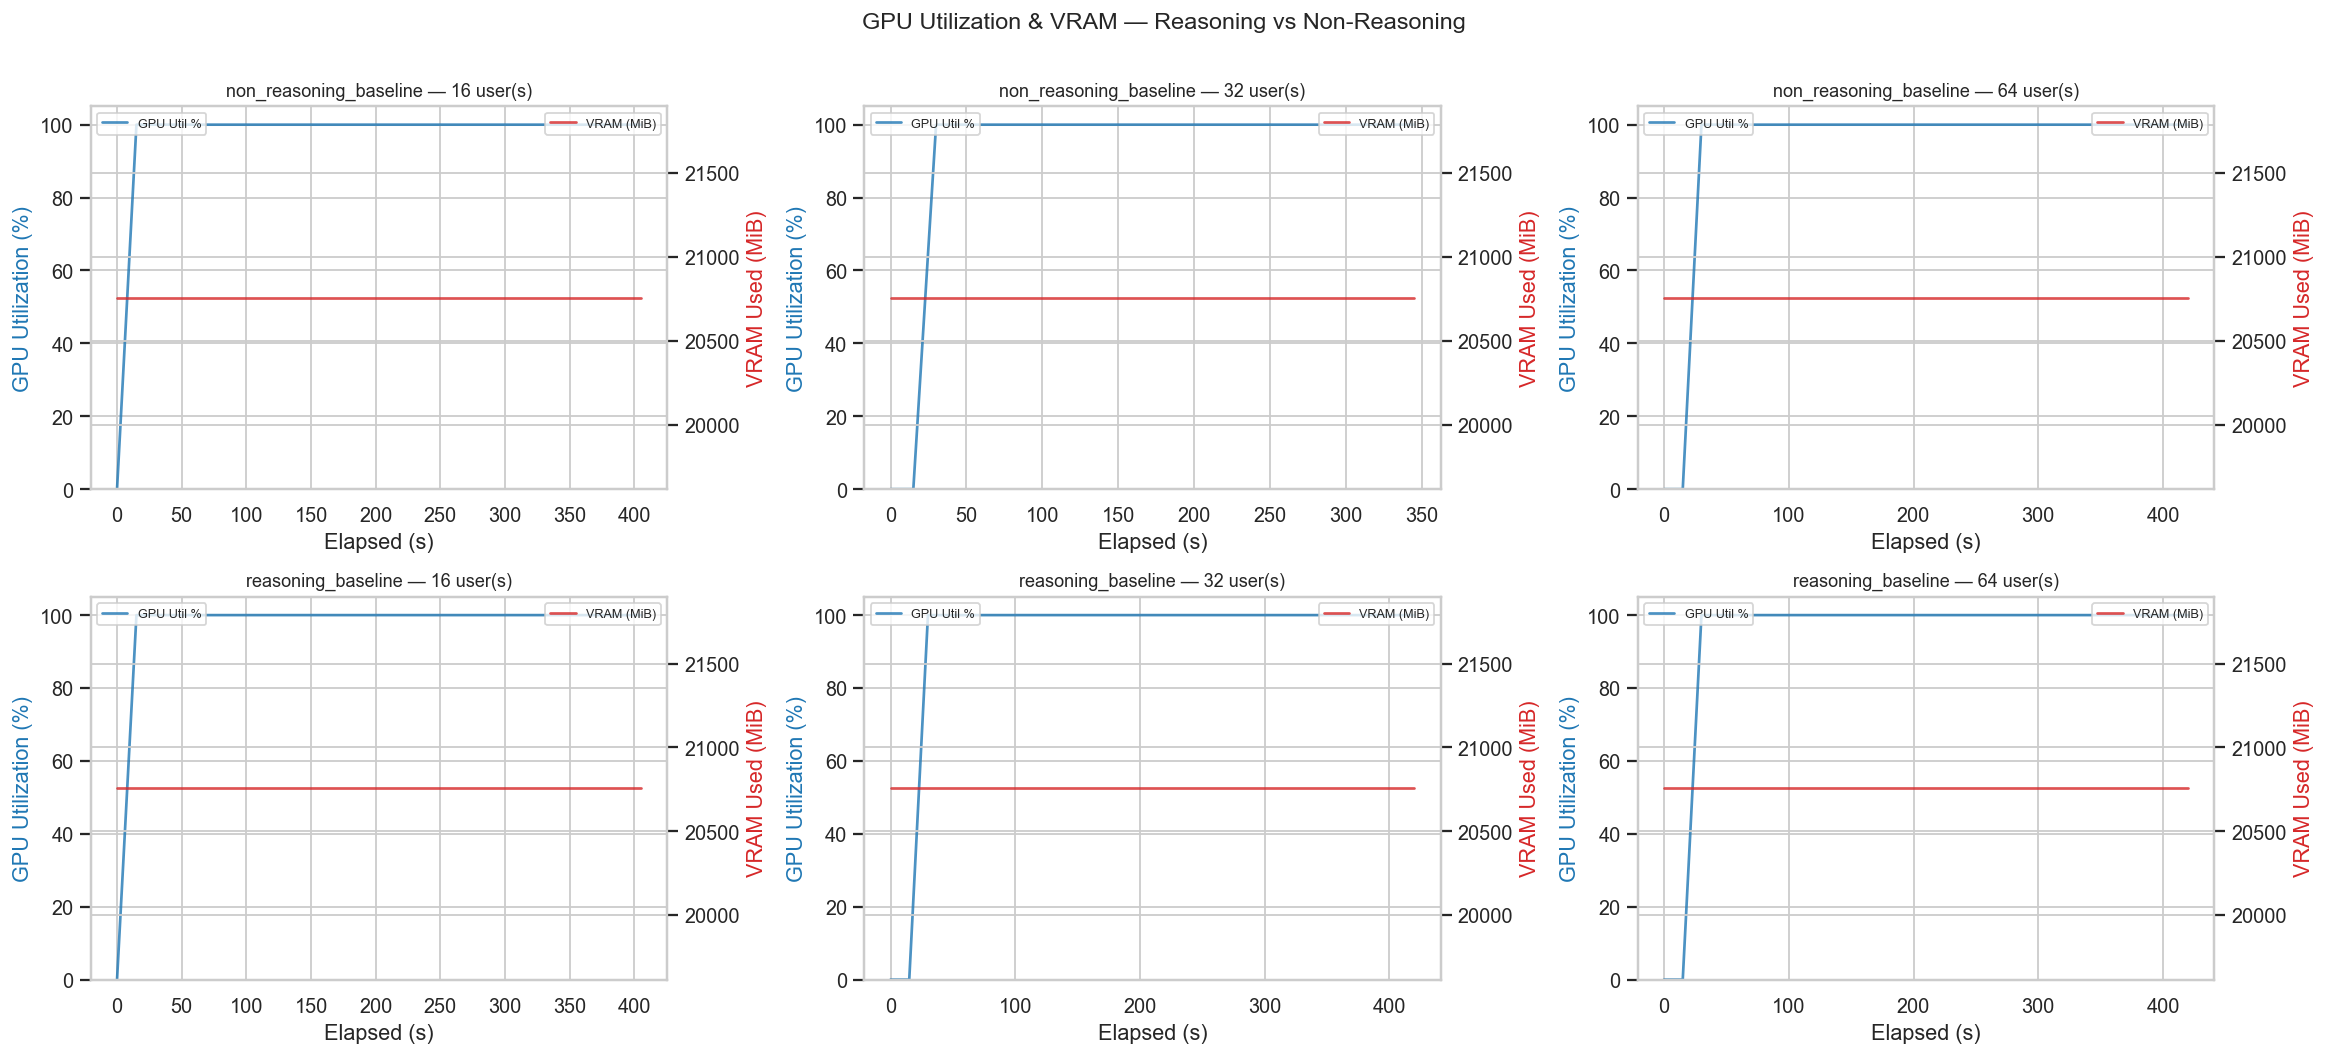

In [27]:
# ─── GPU Utilization & VRAM Time Series (Run 1) ──────────────────────────────
if not prom_wide1.empty and 'gpu_util_pct' in prom_wide1.columns:
    combos = prom_wide1.groupby(['experiment', 'users']).ngroups
    n_cols = min(3, combos)
    n_rows = (combos + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for idx, ((exp, u), grp) in enumerate(prom_wide1.groupby(['experiment', 'users'])):
        if idx >= len(axes_flat):
            break
        ax = axes_flat[idx]
        ax2 = ax.twinx()

        ax.plot(grp['elapsed_s'], grp['gpu_util_pct'], color='tab:blue', alpha=0.8, label='GPU Util %')
        if 'gpu_fb_used_mib' in grp.columns:
            ax2.plot(grp['elapsed_s'], grp['gpu_fb_used_mib'], color='tab:red', alpha=0.8, label='VRAM (MiB)')

        ax.set_ylim(0, 105)
        ax.set_ylabel('GPU Utilization (%)', color='tab:blue')
        ax2.set_ylabel('VRAM Used (MiB)', color='tab:red')
        ax.set_xlabel('Elapsed (s)')
        ax.set_title(f'{exp} — {u} user(s)', fontsize=10)
        ax.legend(loc='upper left', fontsize=7)
        ax2.legend(loc='upper right', fontsize=7)

    for idx_ax in range(idx + 1, len(axes_flat)):
        axes_flat[idx_ax].set_visible(False)

    fig.suptitle('GPU Utilization & VRAM — Reasoning vs Non-Reasoning', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(run1_dir / 'gpu_utilization_timeseries.png', bbox_inches='tight')
    plt.show()
else:
    print('⚠ Skipping GPU time series — no GPU metrics available in Run 1.')

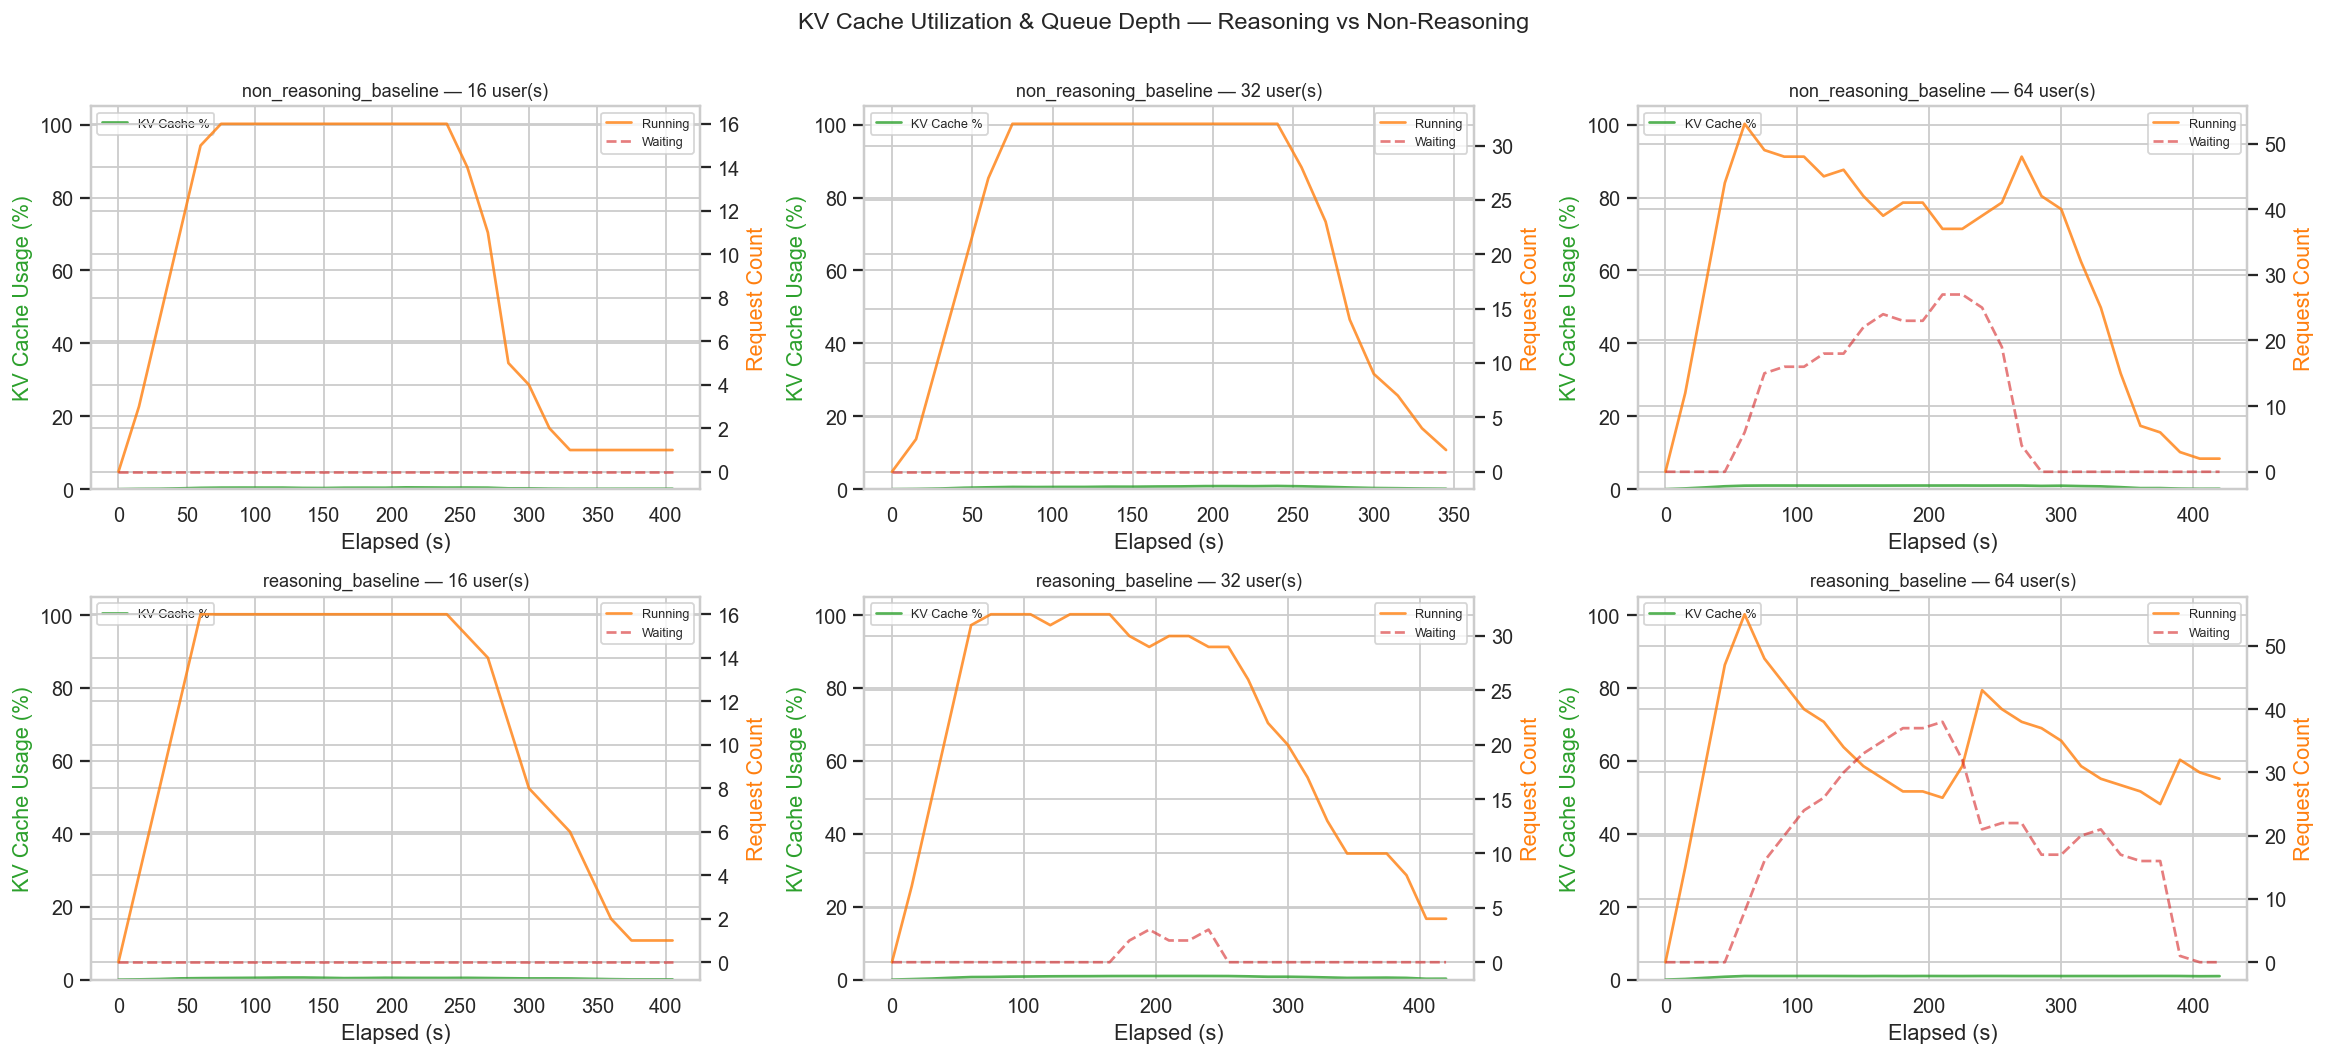

In [28]:
# ─── KV Cache & Queue Depth Time Series (Run 1) ──────────────────────────────
if not prom_wide1.empty and 'kv_cache_usage_pct' in prom_wide1.columns:
    combos = prom_wide1.groupby(['experiment', 'users']).ngroups
    n_cols = min(3, combos)
    n_rows = (combos + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for idx, ((exp, u), grp) in enumerate(prom_wide1.groupby(['experiment', 'users'])):
        if idx >= len(axes_flat):
            break
        ax = axes_flat[idx]
        ax2 = ax.twinx()

        ax.plot(grp['elapsed_s'], grp['kv_cache_usage_pct'], color='tab:green', alpha=0.8, label='KV Cache %')
        if 'requests_running' in grp.columns:
            ax2.plot(grp['elapsed_s'], grp['requests_running'], color='tab:orange', alpha=0.8, label='Running')
        if 'requests_waiting' in grp.columns:
            ax2.plot(grp['elapsed_s'], grp['requests_waiting'], color='tab:red', alpha=0.6, linestyle='--', label='Waiting')

        ax.set_ylim(0, 105)
        ax.set_ylabel('KV Cache Usage (%)', color='tab:green')
        ax2.set_ylabel('Request Count', color='tab:orange')
        ax.set_xlabel('Elapsed (s)')
        ax.set_title(f'{exp} — {u} user(s)', fontsize=10)
        ax.legend(loc='upper left', fontsize=7)
        ax2.legend(loc='upper right', fontsize=7)

    for idx_ax in range(idx + 1, len(axes_flat)):
        axes_flat[idx_ax].set_visible(False)

    fig.suptitle('KV Cache Utilization & Queue Depth — Reasoning vs Non-Reasoning', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(run1_dir / 'kv_cache_timeseries.png', bbox_inches='tight')
    plt.show()
else:
    print('⚠ Skipping KV cache time series — no vLLM metrics available in Run 1.')

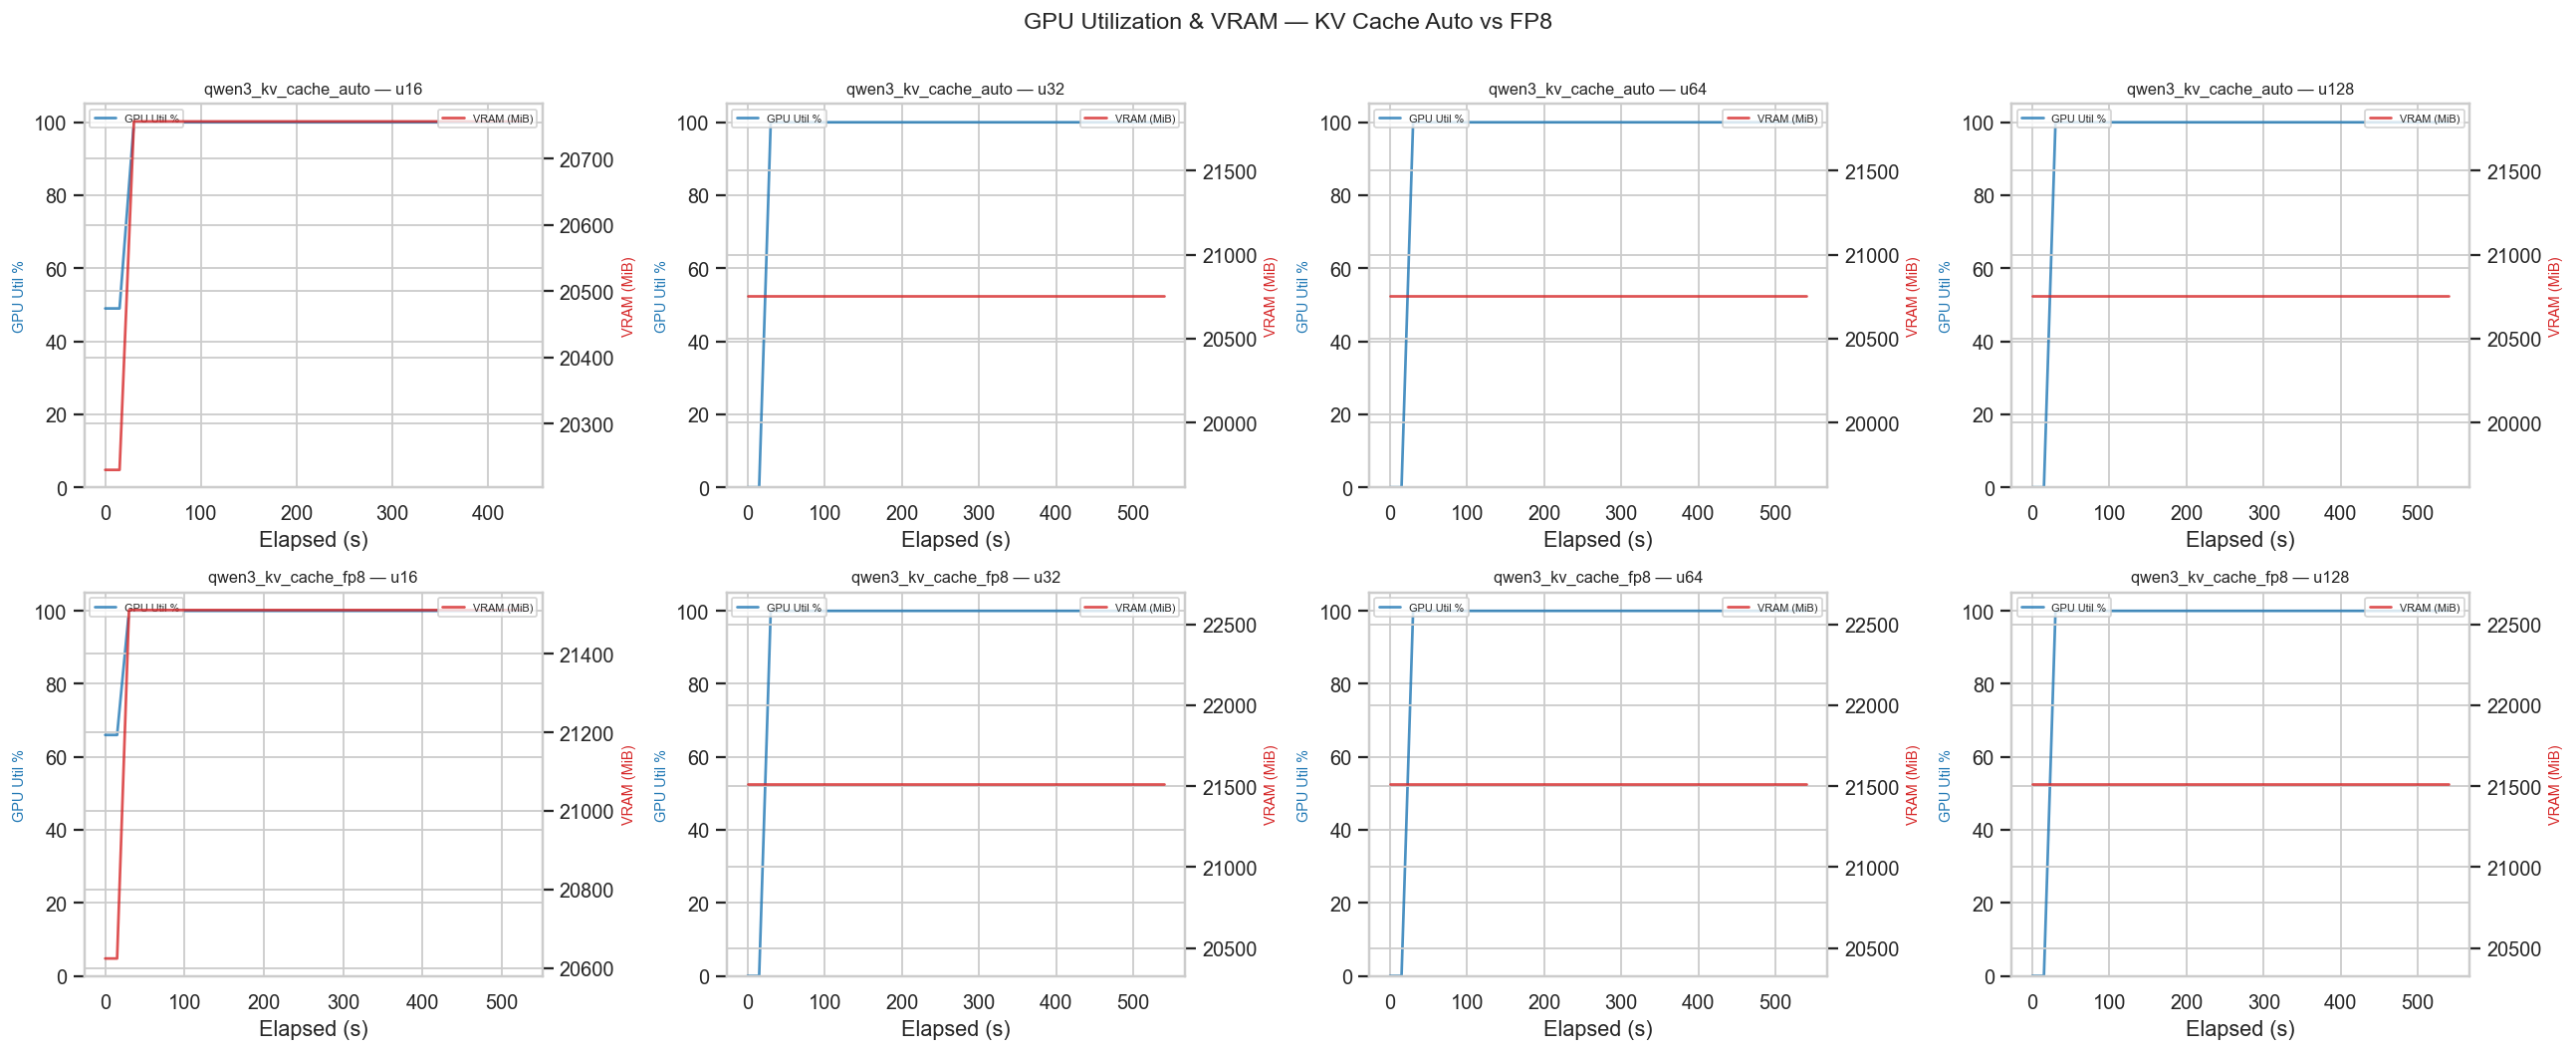

In [29]:
# ─── GPU Utilization & VRAM Time Series (Run 2) ──────────────────────────────
if not prom_wide2.empty and 'gpu_util_pct' in prom_wide2.columns:
    combos = prom_wide2.groupby(['experiment', 'users']).ngroups
    n_cols = min(4, combos)
    n_rows = (combos + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for idx, ((exp, u), grp) in enumerate(prom_wide2.groupby(['experiment', 'users'])):
        if idx >= len(axes_flat):
            break
        ax = axes_flat[idx]
        ax2 = ax.twinx()

        ax.plot(grp['elapsed_s'], grp['gpu_util_pct'], color='tab:blue', alpha=0.8, label='GPU Util %')
        if 'gpu_fb_used_mib' in grp.columns:
            ax2.plot(grp['elapsed_s'], grp['gpu_fb_used_mib'], color='tab:red', alpha=0.8, label='VRAM (MiB)')

        ax.set_ylim(0, 105)
        ax.set_ylabel('GPU Util %', color='tab:blue', fontsize=8)
        ax2.set_ylabel('VRAM (MiB)', color='tab:red', fontsize=8)
        ax.set_xlabel('Elapsed (s)')
        ax.set_title(f'{exp} — u{u}', fontsize=9)
        ax.legend(loc='upper left', fontsize=6)
        ax2.legend(loc='upper right', fontsize=6)

    for idx_ax in range(idx + 1, len(axes_flat)):
        axes_flat[idx_ax].set_visible(False)

    fig.suptitle('GPU Utilization & VRAM — KV Cache Auto vs FP8', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(run2_dir / 'gpu_utilization_timeseries.png', bbox_inches='tight')
    plt.show()
else:
    print('⚠ Skipping GPU time series — no GPU metrics available in Run 2.')

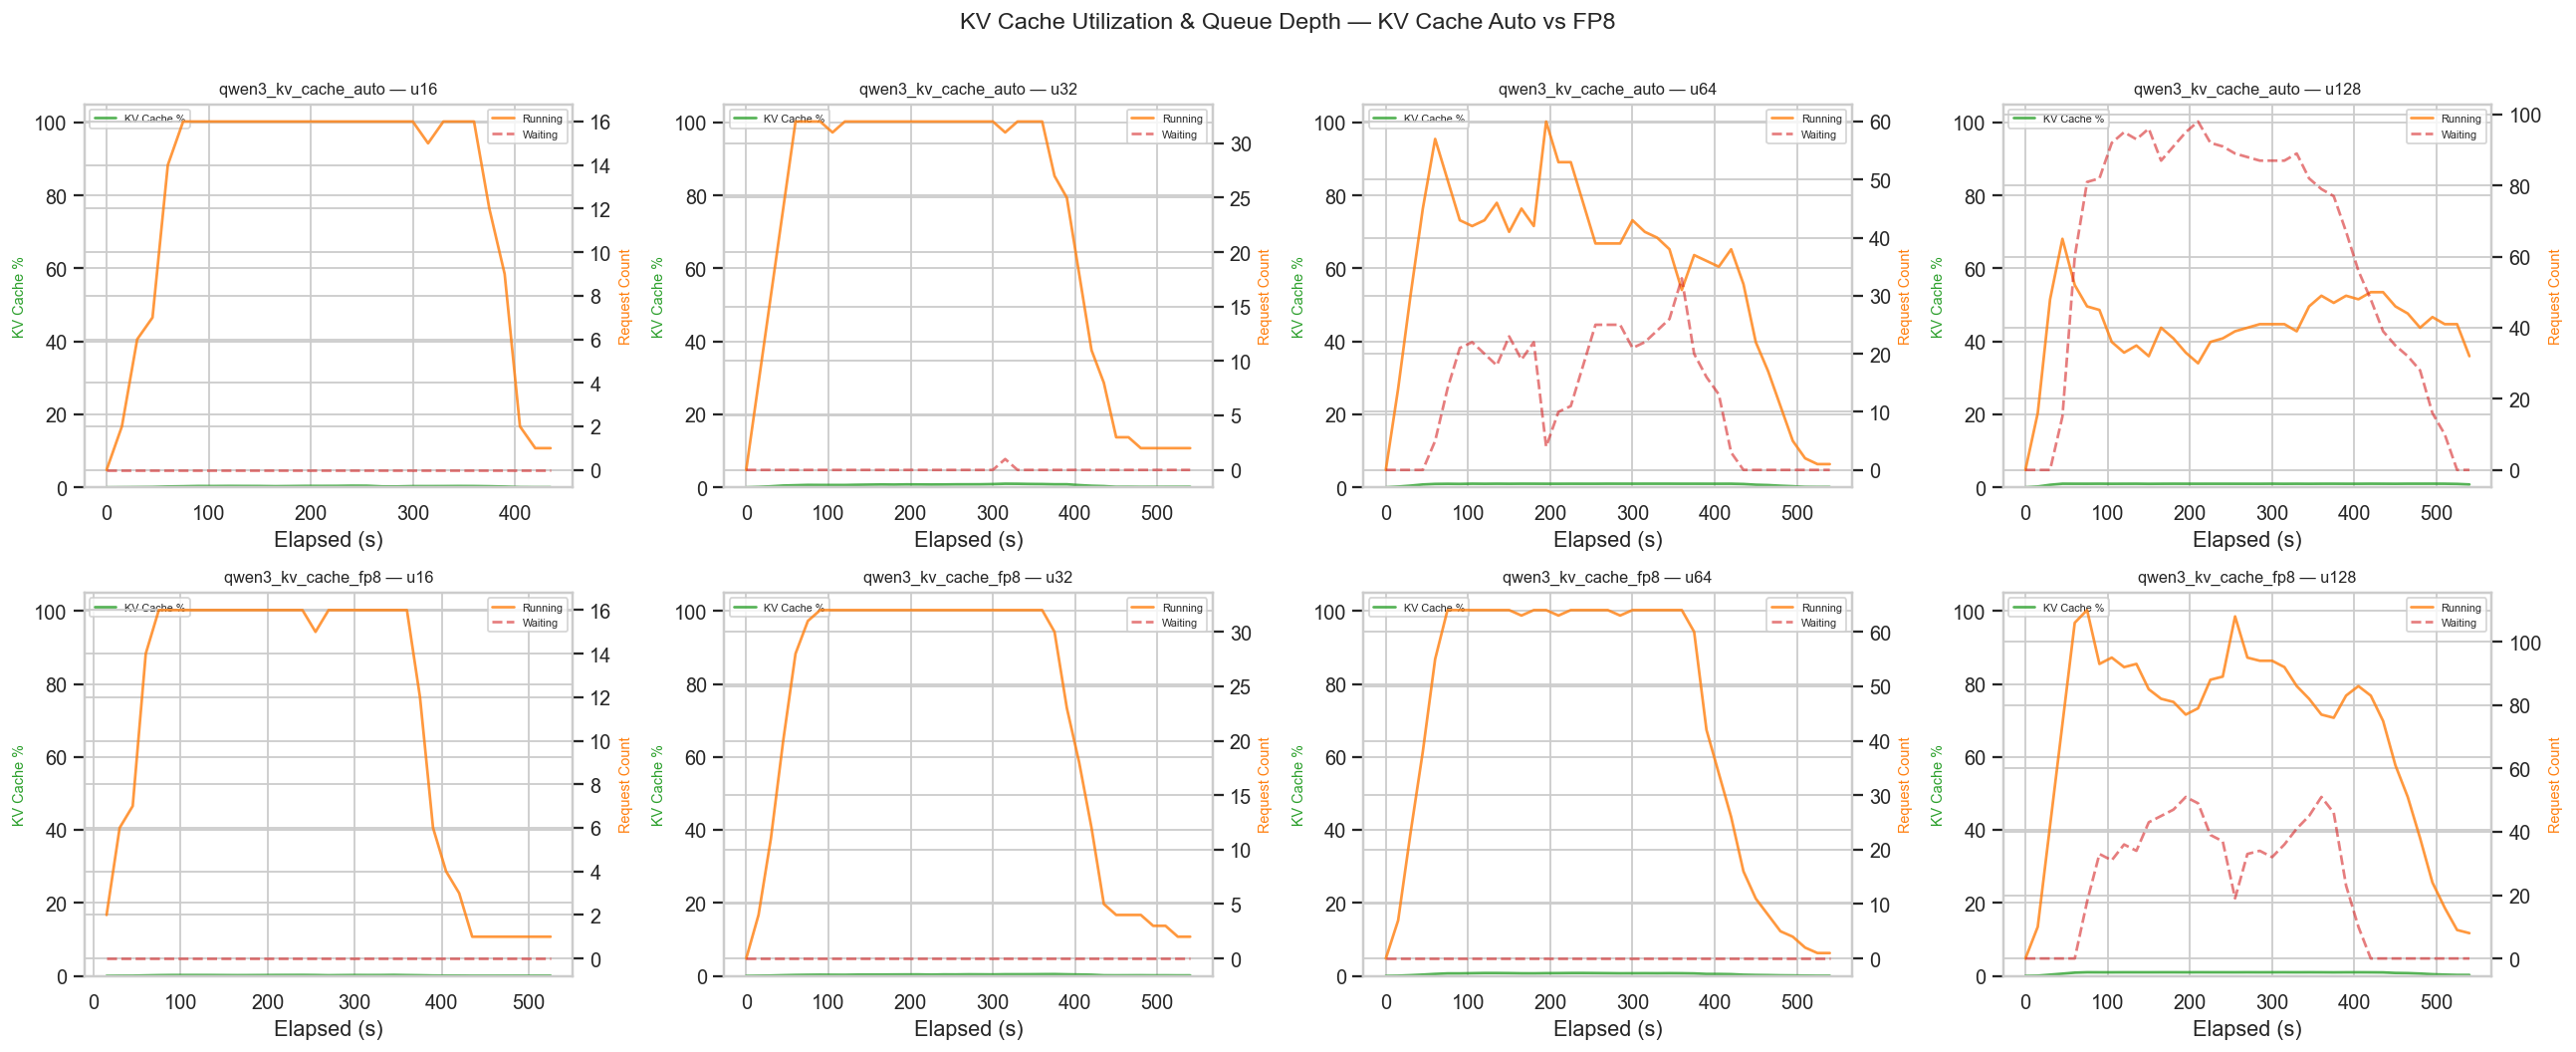

In [30]:
# ─── KV Cache & Queue Depth Time Series (Run 2) ──────────────────────────────
if not prom_wide2.empty and 'kv_cache_usage_pct' in prom_wide2.columns:
    combos = prom_wide2.groupby(['experiment', 'users']).ngroups
    n_cols = min(4, combos)
    n_rows = (combos + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for idx, ((exp, u), grp) in enumerate(prom_wide2.groupby(['experiment', 'users'])):
        if idx >= len(axes_flat):
            break
        ax = axes_flat[idx]
        ax2 = ax.twinx()

        ax.plot(grp['elapsed_s'], grp['kv_cache_usage_pct'], color='tab:green', alpha=0.8, label='KV Cache %')
        if 'requests_running' in grp.columns:
            ax2.plot(grp['elapsed_s'], grp['requests_running'], color='tab:orange', alpha=0.8, label='Running')
        if 'requests_waiting' in grp.columns:
            ax2.plot(grp['elapsed_s'], grp['requests_waiting'], color='tab:red', alpha=0.6, linestyle='--', label='Waiting')

        ax.set_ylim(0, 105)
        ax.set_ylabel('KV Cache %', color='tab:green', fontsize=8)
        ax2.set_ylabel('Request Count', color='tab:orange', fontsize=8)
        ax.set_xlabel('Elapsed (s)')
        ax.set_title(f'{exp} — u{u}', fontsize=9)
        ax.legend(loc='upper left', fontsize=6)
        ax2.legend(loc='upper right', fontsize=6)

    for idx_ax in range(idx + 1, len(axes_flat)):
        axes_flat[idx_ax].set_visible(False)

    fig.suptitle('KV Cache Utilization & Queue Depth — KV Cache Auto vs FP8', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(run2_dir / 'kv_cache_timeseries.png', bbox_inches='tight')
    plt.show()
else:
    print('⚠ Skipping KV cache time series — no vLLM metrics available in Run 2.')

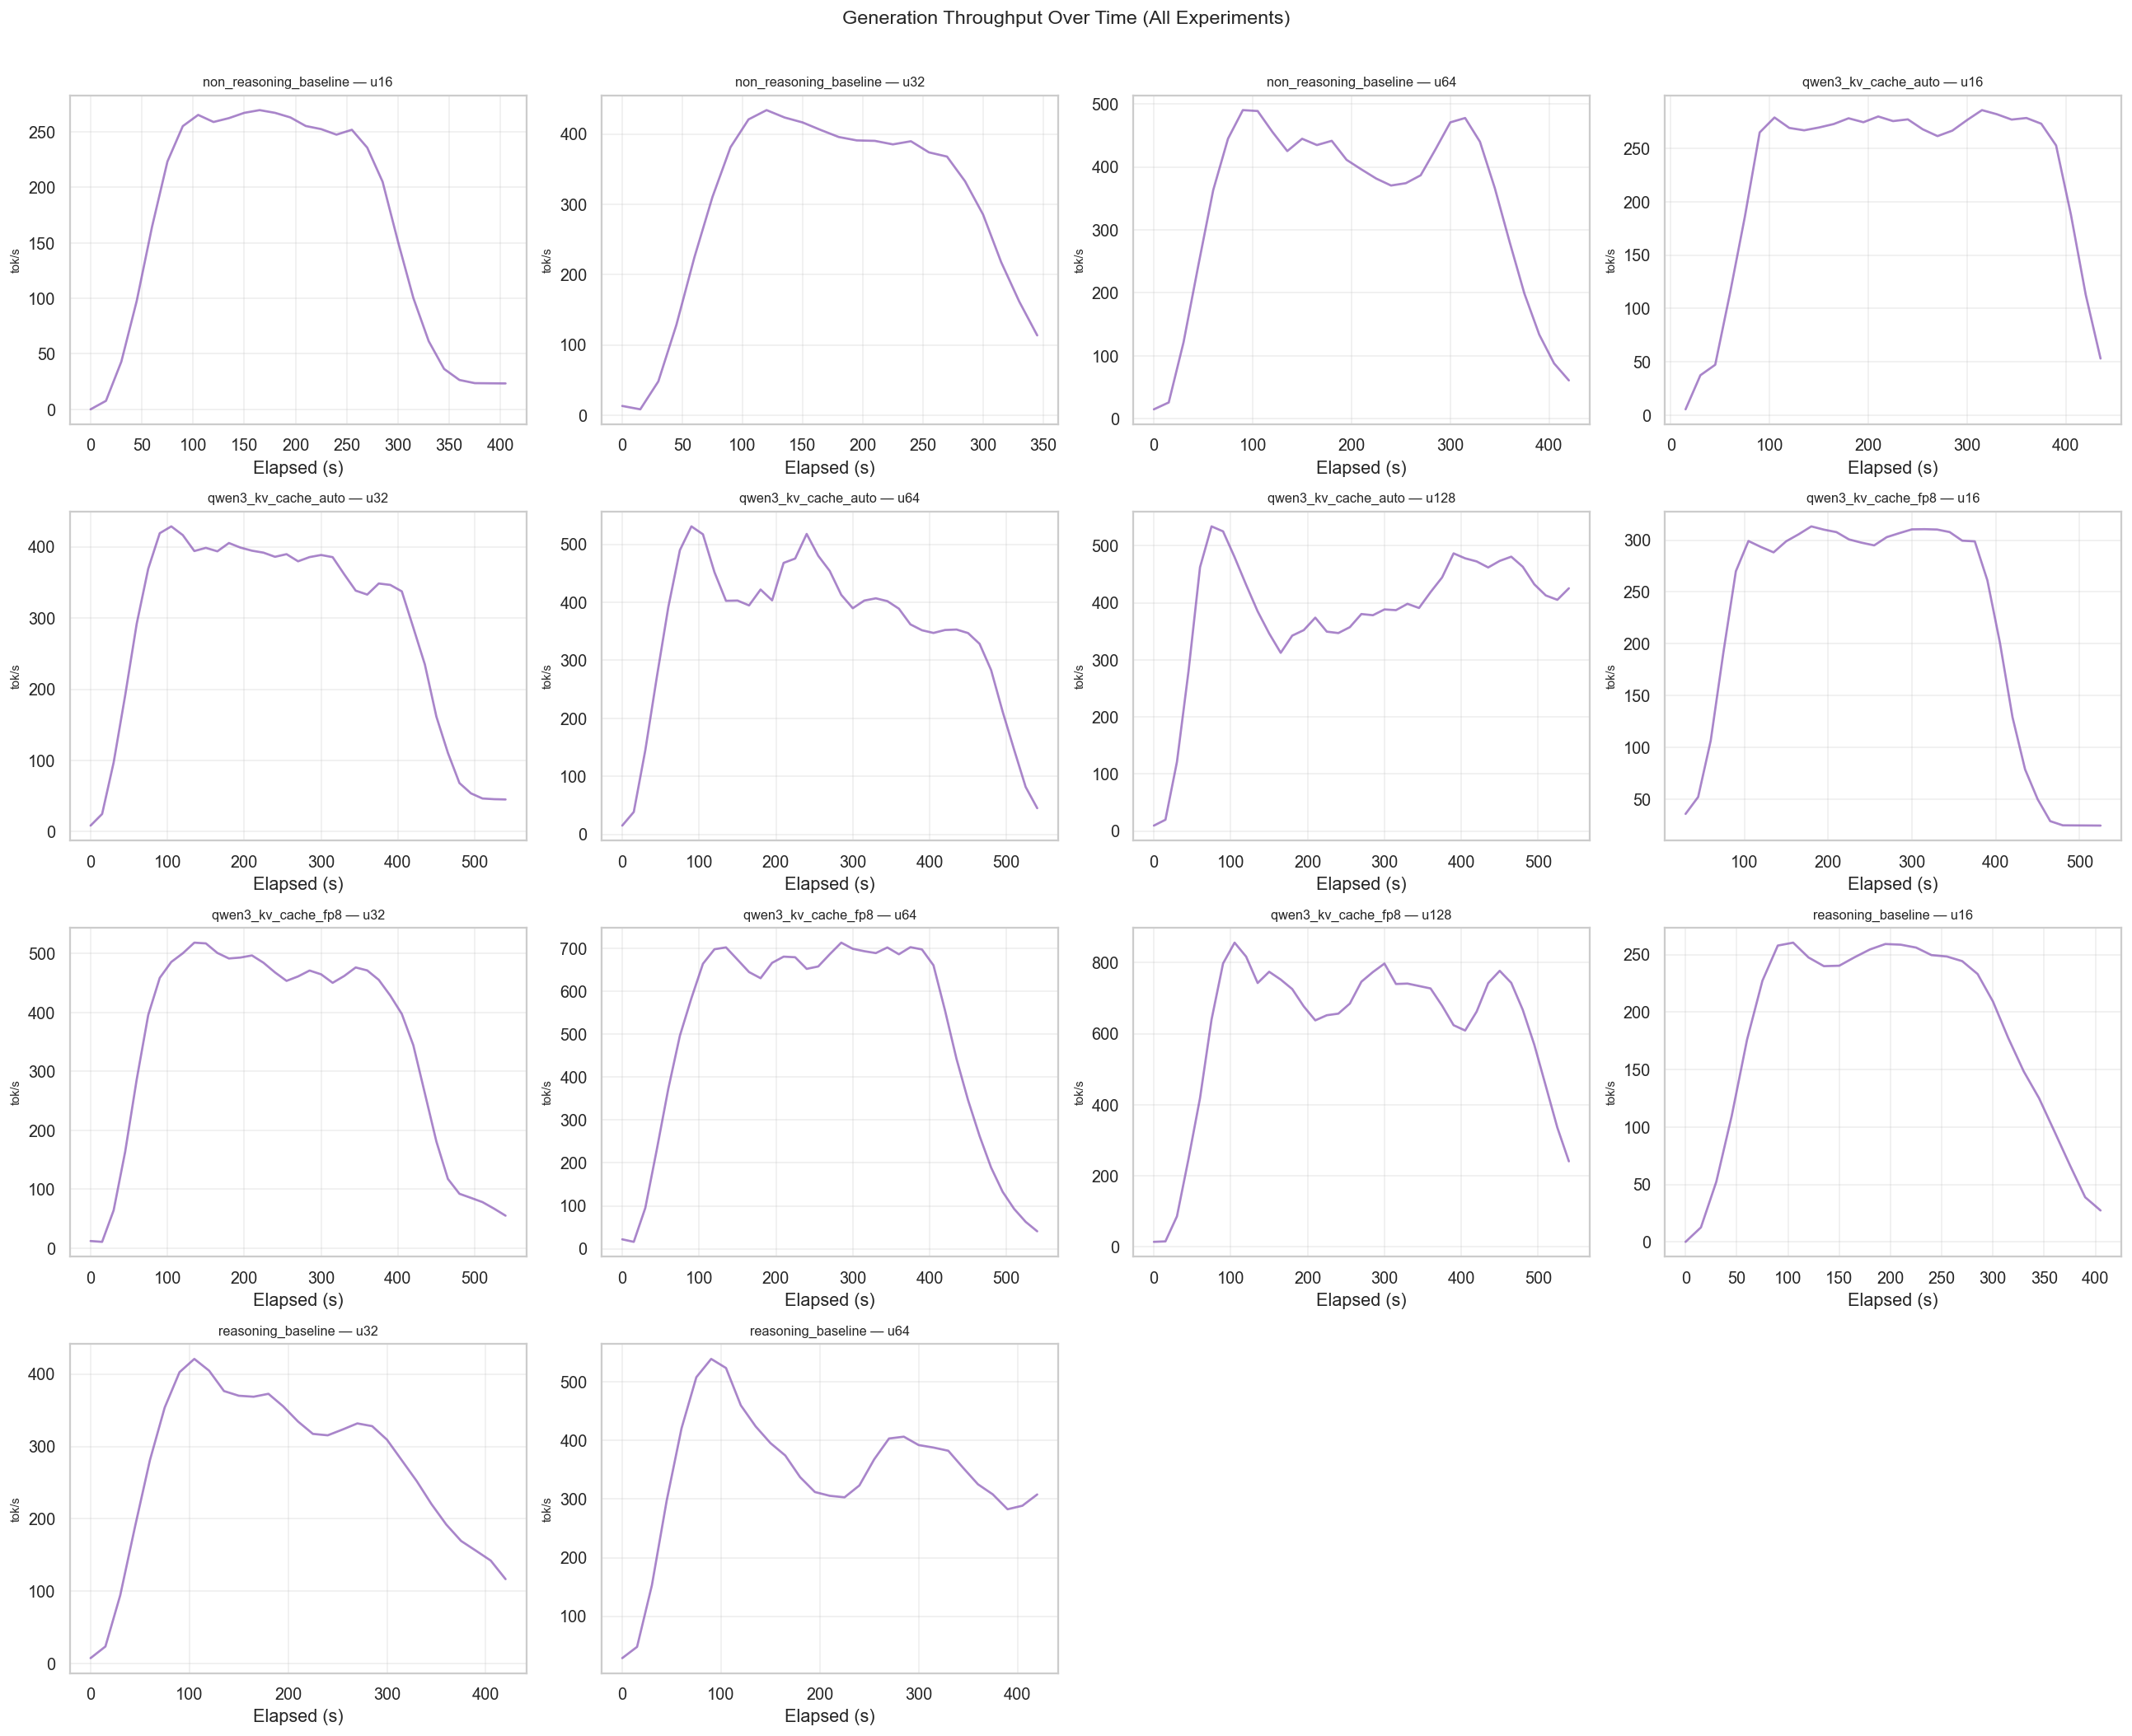

In [31]:
# ─── Generation Throughput Time Series (Both Runs) ───────────────────────────
if not prom_wide.empty and 'generation_tokens_per_sec' in prom_wide.columns:
    combos = prom_wide.groupby(['experiment', 'users']).ngroups
    n_cols = min(4, combos)
    n_rows = (combos + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    for idx, ((exp, u), grp) in enumerate(prom_wide.groupby(['experiment', 'users'])):
        if idx >= len(axes_flat):
            break
        ax = axes_flat[idx]
        ax.plot(grp['elapsed_s'], grp['generation_tokens_per_sec'], color='tab:purple', alpha=0.8)
        ax.set_ylabel('tok/s', fontsize=8)
        ax.set_xlabel('Elapsed (s)')
        ax.set_title(f'{exp} — u{u}', fontsize=9)
        ax.grid(True, alpha=0.3)

    for idx_ax in range(idx + 1, len(axes_flat)):
        axes_flat[idx_ax].set_visible(False)

    fig.suptitle('Generation Throughput Over Time (All Experiments)', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('⚠ No generation throughput data available.')

## Cross-Experiment Server-Side Summary

Aggregate GPU, KV cache, and throughput metrics across experiments.

In [32]:
# ─── Server-Side Summary Table ───────────────────────────────────────────────
if not prom_wide.empty:
    agg_cols = {}
    if 'gpu_util_pct' in prom_wide.columns:
        agg_cols['gpu_util_mean'] = ('gpu_util_pct', 'mean')
        agg_cols['gpu_util_max']  = ('gpu_util_pct', 'max')
    if 'gpu_fb_used_mib' in prom_wide.columns:
        agg_cols['vram_mean_mib'] = ('gpu_fb_used_mib', 'mean')
        agg_cols['vram_max_mib']  = ('gpu_fb_used_mib', 'max')
    if 'kv_cache_usage_pct' in prom_wide.columns:
        agg_cols['kv_cache_mean_pct'] = ('kv_cache_usage_pct', 'mean')
        agg_cols['kv_cache_max_pct']  = ('kv_cache_usage_pct', 'max')
    if 'requests_running' in prom_wide.columns:
        agg_cols['requests_running_mean'] = ('requests_running', 'mean')
    if 'requests_waiting' in prom_wide.columns:
        agg_cols['requests_waiting_mean'] = ('requests_waiting', 'mean')
        agg_cols['requests_waiting_max']  = ('requests_waiting', 'max')
    if 'generation_tokens_per_sec' in prom_wide.columns:
        agg_cols['gen_throughput_mean'] = ('generation_tokens_per_sec', 'mean')

    server_summary = (
        prom_wide.groupby(['experiment', 'users'])
        .agg(**agg_cols)
        .reset_index()
    )
    
    pd.set_option('display.float_format', '{:.1f}'.format)
    print('Server-Side Summary (all experiments):')
    display(server_summary)
else:
    print('⚠ No Prometheus metrics to summarize.')

Server-Side Summary (all experiments):


,experiment,users,gpu_util_mean,gpu_util_max,vram_mean_mib,vram_max_mib,kv_cache_mean_pct,kv_cache_max_pct,requests_running_mean,requests_waiting_mean,requests_waiting_max,gen_throughput_mean
0,non_reasoning_baseline,16,96.4,100.0,20756.0,20756.0,0.3,0.5,9.6,0.0,0.0,162.2
1,non_reasoning_baseline,32,91.7,100.0,20756.0,20756.0,0.5,0.9,22.1,0.0,0.0,292.5
2,non_reasoning_baseline,64,93.1,100.0,20756.0,20756.0,0.7,1.0,31.4,9.8,27.0,333.1
3,qwen3_kv_cache_auto,16,96.6,100.0,20720.9,20756.0,0.3,0.4,12.4,0.0,0.0,223.2
4,qwen3_kv_cache_auto,32,94.6,100.0,20756.0,20756.0,0.6,1.0,22.2,0.0,1.0,282.6
5,qwen3_kv_cache_auto,64,94.6,100.0,20756.0,20756.0,0.8,1.0,34.0,12.4,33.0,348.2
6,qwen3_kv_cache_auto,128,94.6,100.0,20756.0,20756.0,0.9,1.0,40.2,61.2,98.0,383.9
7,qwen3_kv_cache_fp8,16,98.1,100.0,21462.7,21512.0,0.2,0.3,10.9,0.0,0.0,213.5
8,qwen3_kv_cache_fp8,32,94.6,100.0,21512.0,21512.0,0.3,0.5,21.9,0.0,0.0,341.1
9,qwen3_kv_cache_fp8,64,94.6,100.0,21512.0,21512.0,0.5,0.8,43.5,0.0,0.0,492.8


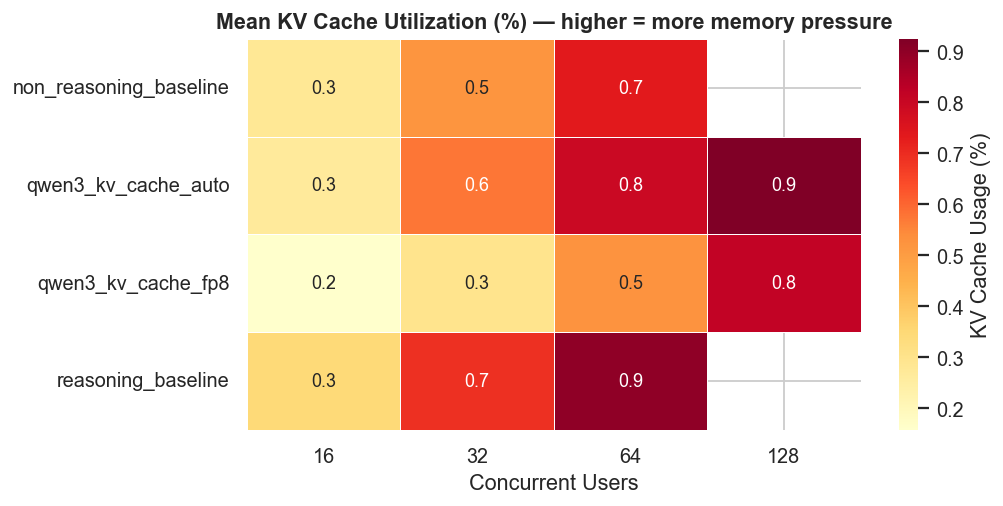

In [33]:
# ─── KV Cache Heatmap ─────────────────────────────────────────────────────────
if not prom_wide.empty and 'kv_cache_usage_pct' in prom_wide.columns:
    pivot_kv = server_summary.pivot_table(
        index='experiment', columns='users', values='kv_cache_mean_pct', aggfunc='mean'
    )
    fig, ax = plt.subplots(figsize=(max(8, pivot_kv.shape[1] * 2), max(4, pivot_kv.shape[0] * 0.8)))
    sns.heatmap(pivot_kv, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'KV Cache Usage (%)'})
    ax.set_title('Mean KV Cache Utilization (%) — higher = more memory pressure', fontweight='bold')
    ax.set_xlabel('Concurrent Users')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()
else:
    print('⚠ No KV cache data for heatmap.')

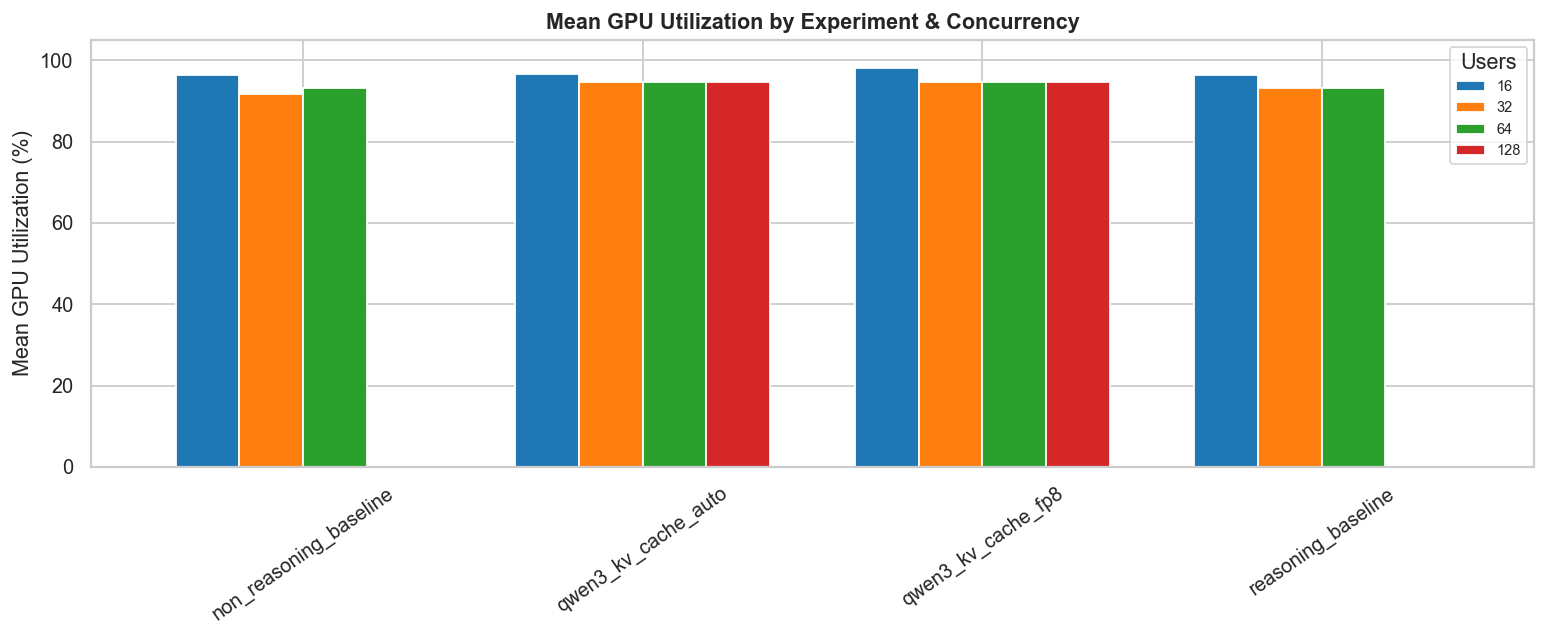

In [34]:
# ─── GPU Utilization Bar Chart (All Experiments) ──────────────────────────────
if not prom_wide.empty and 'gpu_util_pct' in prom_wide.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    gpu_pivot = server_summary.pivot(index='experiment', columns='users', values='gpu_util_mean')
    gpu_pivot.plot(kind='bar', ax=ax, width=0.75)
    ax.set_ylabel('Mean GPU Utilization (%)')
    ax.set_xlabel('')
    ax.set_title('Mean GPU Utilization by Experiment & Concurrency', fontweight='bold')
    ax.legend(title='Users', fontsize=8)
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=35)
    plt.tight_layout()
    plt.show()

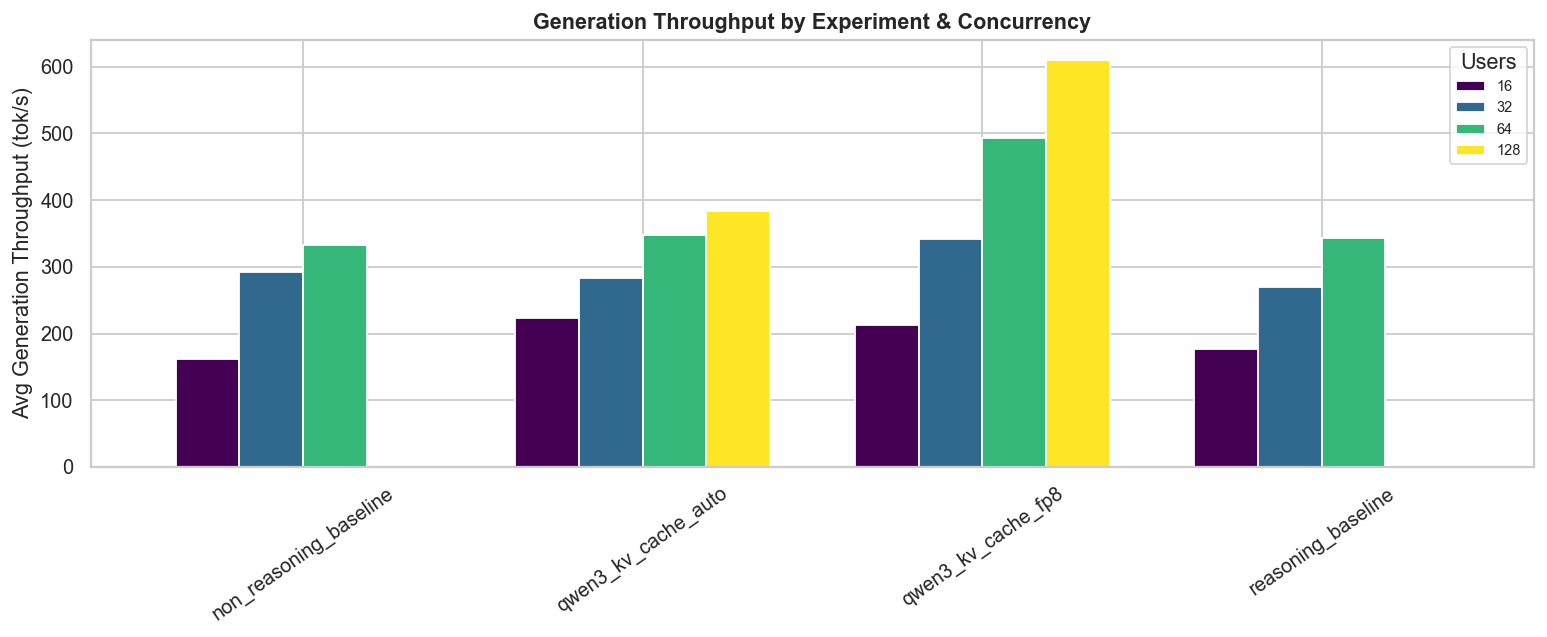

In [35]:
# ─── Generation Throughput Bar Chart (All Experiments) ────────────────────────
if not prom_wide.empty and 'generation_tokens_per_sec' in prom_wide.columns:
    fig, ax = plt.subplots(figsize=(12, 5))
    tp_pivot = server_summary.pivot(index='experiment', columns='users', values='gen_throughput_mean')
    tp_pivot.plot(kind='bar', ax=ax, width=0.75, colormap='viridis')
    ax.set_ylabel('Avg Generation Throughput (tok/s)')
    ax.set_xlabel('')
    ax.set_title('Generation Throughput by Experiment & Concurrency', fontweight='bold')
    ax.legend(title='Users', fontsize=8)
    ax.tick_params(axis='x', rotation=35)
    plt.tight_layout()
    plt.show()

---
# Unified Summary & Correlation Analysis

In [36]:
# ─── Unified Summary: Merge Locust + Prometheus metrics ──────────────────────
summary_all = build_summary(df_ok)

unified = summary_all.groupby(['experiment', 'users']).agg(
    n          = ('n', 'sum'),
    ttft_mean  = ('ttft_mean', 'mean'),
    ttft_p99   = ('ttft_p99', 'max'),
    tpot_mean  = ('tpot_mean', 'mean'),
    e2e_mean   = ('e2e_mean', 'mean'),
).reset_index()

if not prom_wide.empty:
    merge_cols = ['experiment', 'users']
    server_cols = [c for c in server_summary.columns if c not in ['experiment', 'users']]
    unified = unified.merge(
        server_summary[merge_cols + server_cols],
        on=merge_cols, how='left'
    )

print('Unified summary (all experiments):')
display(unified)

Unified summary (all experiments):


,experiment,users,n,ttft_mean,ttft_p99,tpot_mean,e2e_mean,gpu_util_mean,gpu_util_max,vram_mean_mib,vram_max_mib,kv_cache_mean_pct,kv_cache_max_pct,requests_running_mean,requests_waiting_mean,requests_waiting_max,gen_throughput_mean
0,non_reasoning_baseline,16,80,274.7,955.0,58.8,31638.6,96.4,100.0,20756.0,20756.0,0.3,0.5,9.6,0.0,0.0,162.2
1,non_reasoning_baseline,32,125,288.8,818.9,76.4,45080.1,91.7,100.0,20756.0,20756.0,0.5,0.9,22.1,0.0,0.0,292.5
2,non_reasoning_baseline,64,181,24416.7,55036.3,96.9,65184.5,93.1,100.0,20756.0,20756.0,0.7,1.0,31.4,9.8,27.0,333.1
3,qwen3_kv_cache_auto,16,131,325.4,7574.9,60.3,22775.4,96.6,100.0,20720.9,20756.0,0.3,0.4,12.4,0.0,0.0,223.2
4,qwen3_kv_cache_auto,32,166,349.9,2143.9,81.9,32265.9,94.6,100.0,20756.0,20756.0,0.6,1.0,22.2,0.0,1.0,282.6
5,qwen3_kv_cache_auto,64,234,24304.7,79297.2,116.7,74576.4,94.6,100.0,20756.0,20756.0,0.8,1.0,34.0,12.4,33.0,348.2
6,qwen3_kv_cache_auto,128,133,90839.6,179360.0,110.3,143932.9,94.6,100.0,20756.0,20756.0,0.9,1.0,40.2,61.2,98.0,383.9
7,qwen3_kv_cache_fp8,16,115,631.3,10291.2,54.0,22978.8,98.1,100.0,21462.7,21512.0,0.2,0.3,10.9,0.0,0.0,213.5
8,qwen3_kv_cache_fp8,32,224,287.2,896.5,70.1,29510.6,94.6,100.0,21512.0,21512.0,0.3,0.5,21.9,0.0,0.0,341.1
9,qwen3_kv_cache_fp8,64,329,327.8,947.0,92.7,38943.0,94.6,100.0,21512.0,21512.0,0.5,0.8,43.5,0.0,0.0,492.8


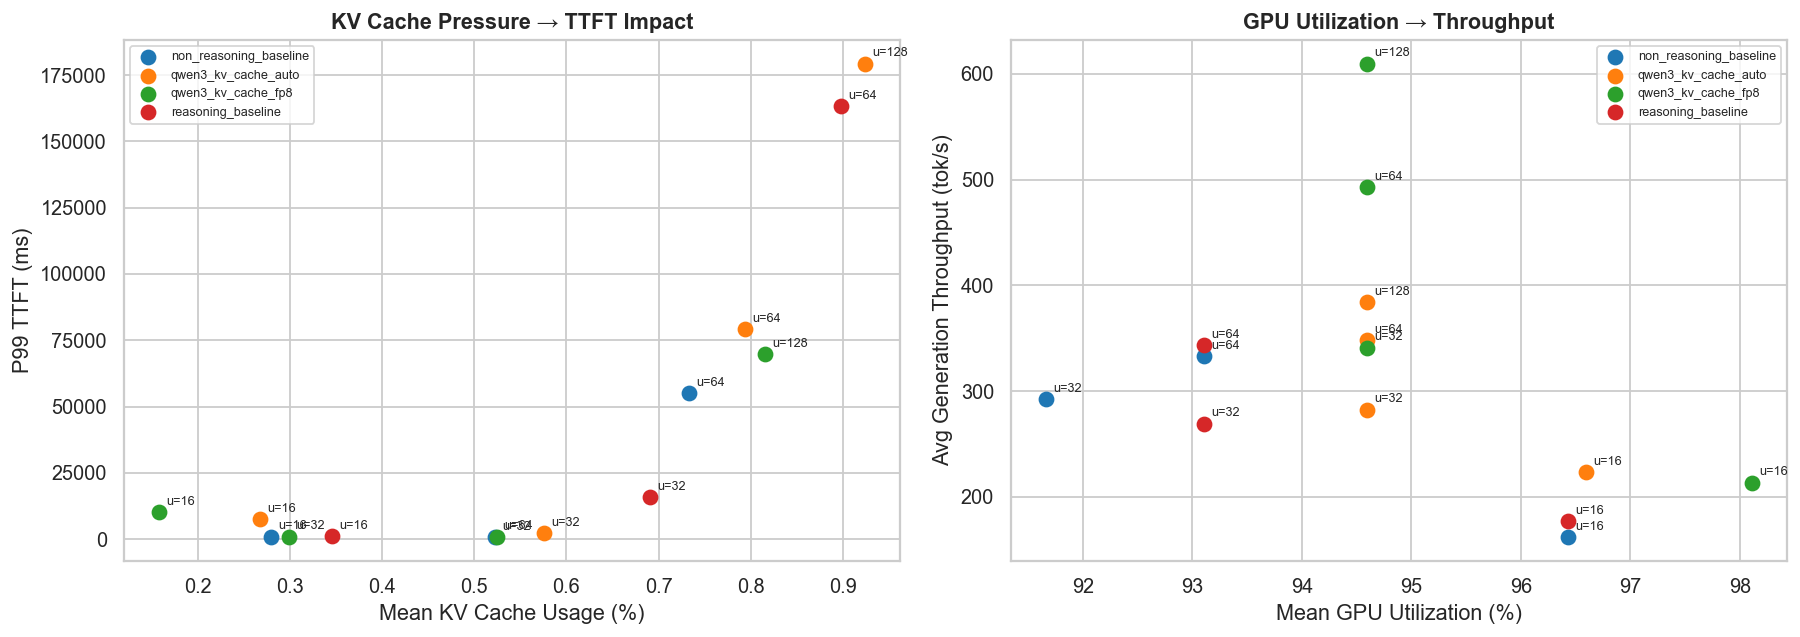

In [37]:
# ─── Correlation: KV Cache / GPU vs Latency/Throughput ───────────────────────
if 'kv_cache_mean_pct' in unified.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # KV Cache vs TTFT P99
    ax1 = axes[0]
    for exp in unified['experiment'].unique():
        sub = unified[unified['experiment'] == exp]
        ax1.scatter(sub['kv_cache_mean_pct'], sub['ttft_p99'], label=exp, s=60)
        for _, row in sub.iterrows():
            ax1.annotate(f'u={int(row["users"])}', (row['kv_cache_mean_pct'], row['ttft_p99']),
                        textcoords='offset points', xytext=(4, 4), fontsize=7)
    ax1.set_xlabel('Mean KV Cache Usage (%)')
    ax1.set_ylabel('P99 TTFT (ms)')
    ax1.set_title('KV Cache Pressure → TTFT Impact', fontweight='bold')
    ax1.legend(fontsize=7)

    # GPU Util vs Generation Throughput
    ax2 = axes[1]
    if 'gpu_util_mean' in unified.columns and 'gen_throughput_mean' in unified.columns:
        for exp in unified['experiment'].unique():
            sub = unified[unified['experiment'] == exp]
            ax2.scatter(sub['gpu_util_mean'], sub['gen_throughput_mean'], label=exp, s=60)
            for _, row in sub.iterrows():
                ax2.annotate(f'u={int(row["users"])}', (row['gpu_util_mean'], row['gen_throughput_mean']),
                            textcoords='offset points', xytext=(4, 4), fontsize=7)
        ax2.set_xlabel('Mean GPU Utilization (%)')
        ax2.set_ylabel('Avg Generation Throughput (tok/s)')
        ax2.set_title('GPU Utilization → Throughput', fontweight='bold')
        ax2.legend(fontsize=7)

    plt.tight_layout()
    plt.show()
else:
    print('⚠ Skipping correlation analysis — missing server metrics.')

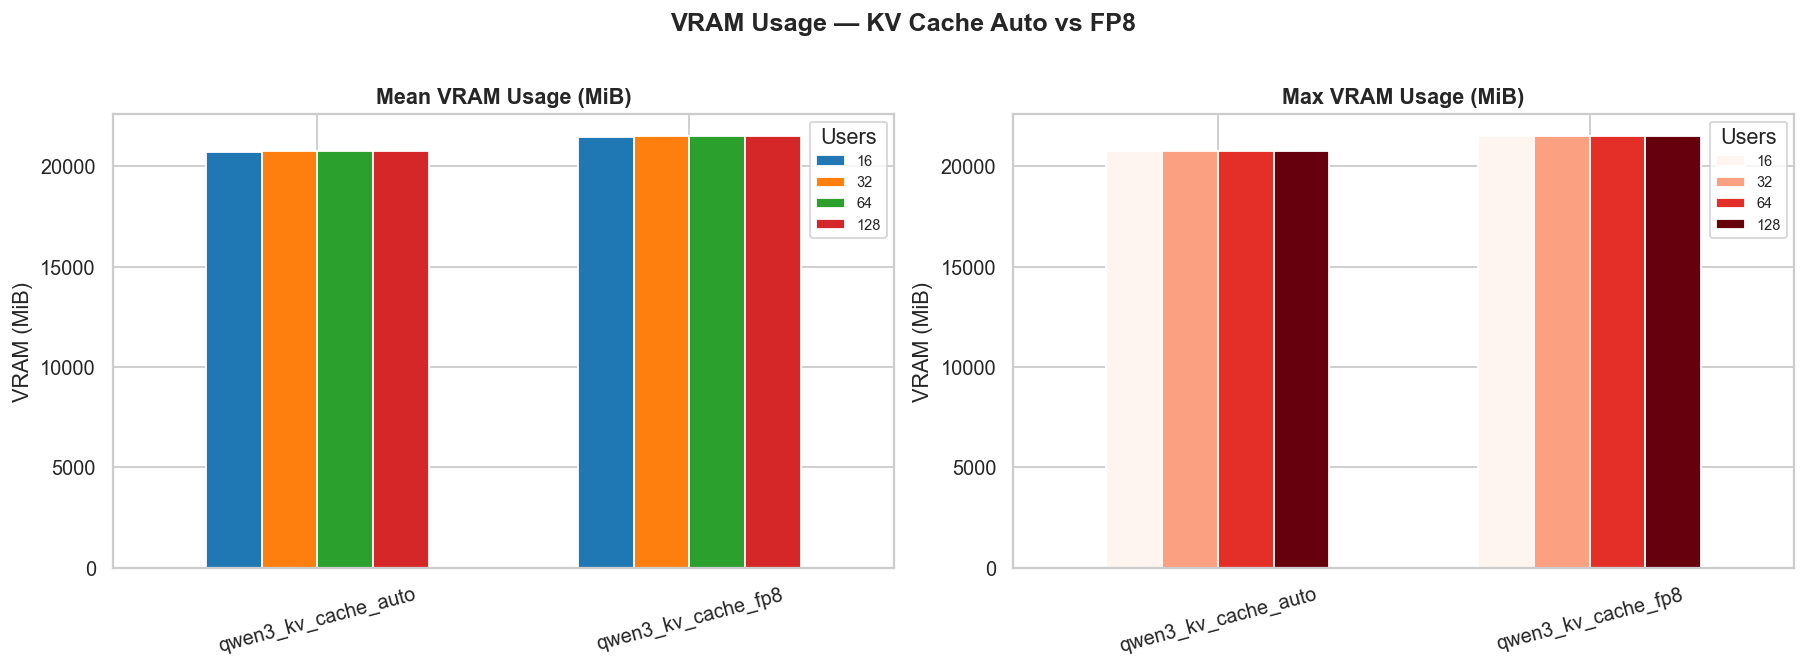

In [38]:
# ─── VRAM Usage Comparison: KV Cache Auto vs FP8 ─────────────────────────────
if not prom_wide2.empty and 'gpu_fb_used_mib' in prom_wide2.columns:
    vram_summary = (
        prom_wide2.groupby(['experiment', 'users'])
        .agg(vram_mean=('gpu_fb_used_mib', 'mean'), vram_max=('gpu_fb_used_mib', 'max'))
        .reset_index()
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Mean VRAM
    pivot_mean = vram_summary.pivot(index='experiment', columns='users', values='vram_mean')
    pivot_mean.plot(kind='bar', ax=axes[0], width=0.6)
    axes[0].set_title('Mean VRAM Usage (MiB)', fontweight='bold')
    axes[0].set_ylabel('VRAM (MiB)')
    axes[0].set_xlabel('')
    axes[0].legend(title='Users', fontsize=8)
    axes[0].tick_params(axis='x', rotation=15)
    
    # Max VRAM
    pivot_max = vram_summary.pivot(index='experiment', columns='users', values='vram_max')
    pivot_max.plot(kind='bar', ax=axes[1], width=0.6, colormap='Reds')
    axes[1].set_title('Max VRAM Usage (MiB)', fontweight='bold')
    axes[1].set_ylabel('VRAM (MiB)')
    axes[1].set_xlabel('')
    axes[1].legend(title='Users', fontsize=8)
    axes[1].tick_params(axis='x', rotation=15)
    
    plt.suptitle('VRAM Usage — KV Cache Auto vs FP8', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(run2_dir / 'vram_comparison.png', bbox_inches='tight')
    plt.show()
else:
    print('⚠ No VRAM data in Run 2.')

In [39]:
# ─── Save unified summary ────────────────────────────────────────────────────
unified_path = RESULTS_ROOT / 'unified_summary_qwen3.csv'
unified.to_csv(unified_path, index=False)
print(f'Unified summary saved to: {unified_path}')
print(f'\n✅ Analysis complete. Grafana snapshots:')
print(f'   Run 1: https://snapshots.raintank.io/dashboard/snapshot/FMUfp7hDpPTDWjL8Its1VRDVYdL4tdTN')
print(f'   Run 2: https://snapshots.raintank.io/dashboard/snapshot/osvbKljgNvc34nwv8z92gkWelXPb0lnH')

Unified summary saved to: results/unified_summary_qwen3.csv

✅ Analysis complete. Grafana snapshots:
   Run 1: https://snapshots.raintank.io/dashboard/snapshot/FMUfp7hDpPTDWjL8Its1VRDVYdL4tdTN
   Run 2: https://snapshots.raintank.io/dashboard/snapshot/osvbKljgNvc34nwv8z92gkWelXPb0lnH
